In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 0. Setup

In [ ]:
# --- Setup:
%pip install -q adversarial-robustness-toolbox torchattacks
%pip install git+https://github.com/fra31/auto-attack

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 13.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.25.1 which is incompatible.
google-adk 1.21.0 requires requests<3.0.0,>=2.32.4, but you have requests 2.25.1 which is incompatible.
sphinx 8.2.3 requires requests>=2.30.0, but you have requests 2.25.

In [ ]:
# --- Imports:
import os, tempfile, random, json
from datetime import datetime, timezone
from typing import Dict, Any, Callable, Optional
import shutil


import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit
from torchvision.models.resnet import ResNet, BasicBlock
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import torchattacks as ta
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import ProjectedGradientDescent, AutoAttack as AutoAttackART, CarliniL2Method, CarliniLInfMethod, CarliniL0Method, DeepFool, FastGradientMethod

from autoattack import AutoAttack as AutoAttackOriginal



In [ ]:
# --- Constants & Device Setup ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# FIXED: Using standard, correct CIFAR-10 stats to avoid bugs and recalculation
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

CIFAR10_CLASSES = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
mean_np = np.array(CIFAR10_MEAN, dtype=np.float32)
std_np = np.array(CIFAR10_STD, dtype=np.float32)

# Create the ART PyTorchClassifier Wrapper for ART attacks
# Reshape clip_min and clip_max for correct broadcasting during clipping in ART
clip_min_reshaped = np.array(CIFAR10_MEAN, dtype=np.float32).reshape(1, -1, 1, 1)
clip_max_reshaped = np.array(CIFAR10_STD, dtype=np.float32).reshape(1, -1, 1, 1)
# Correct clip values should be based on normalized range [0, 1]
clip_min_norm = (0.0 - np.array(CIFAR10_MEAN)) / np.array(CIFAR10_STD)
clip_max_norm = (1.0 - np.array(CIFAR10_MEAN)) / np.array(CIFAR10_STD)

clip_min_reshaped_norm = clip_min_norm.reshape(1, -1, 1, 1)
clip_max_reshaped_norm = clip_max_norm.reshape(1, -1, 1, 1)


std_np  = np.array(CIFAR10_STD, dtype=np.float32)                 # (3,)
mean_np = np.array(CIFAR10_MEAN, dtype=np.float32)                # (3,)
eps = 8/255
# scalar normalized epsilon and step (safe for broadcasting)
n_eps = float((eps / std_np).max())                    # normalized ε (scalar)
n_step = float(n_eps / 4.0)
print(f"Device: {DEVICE} | Torch: {torch.__version__}")
print(f"normalized eps: ", n_eps)
print(f"normalized step: ", n_step)


Device: cuda | Torch: 2.9.0+cu126
normalized eps:  0.12884004414081573
normalized step:  0.032210011035203934


# 1. Datasets and Models

In [ ]:
def get_dataloaders(batch_size=128, num_workers=2, data_root='./data', val_ratio=0.02):
    """Creates CIFAR-10 loaders with a stratified train/val split."""
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
    ])
    transform_eval = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
    ])

    train_aug = datasets.CIFAR10(root=data_root, train=True, download=True, transform=transform_train)
    train_eval = datasets.CIFAR10(root=data_root, train=True, download=False, transform=transform_eval)
    test_set = datasets.CIFAR10(root=data_root, train=False, download=True, transform=transform_eval)

    targets = np.array(train_aug.targets)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=42)
    train_idx, val_idx = next(sss.split(np.zeros_like(targets), targets))

    train_loader = DataLoader(Subset(train_aug, train_idx), batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(Subset(train_eval, val_idx), batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, test_loader

def build_model(num_classes=10):
    """ResNet-18 with CIFAR stem: 3x3 s1 conv, no maxpool."""
    m = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)
    m.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    for mod in m.modules():
        if isinstance(mod, BasicBlock):
            nn.init.constant_(mod.bn2.weight, 0)
    return m

In [ ]:
from torch.utils.data import DataLoader, Subset, random_split

def get_dataloaders_sample(batch_size=1, num_workers=0, data_root='./data',
                            train_size=50, val_size=5, test_size=10, seed=42):
    """
    Tạo các Dataloaders với kích thước mẫu nhỏ, cố định để thử nghiệm (protocol test).

    LƯU Ý: Hàm này sử dụng 'random_split' đơn giản, không dùng StratifiedSplit.
    """
    pin_mem = torch.cuda.is_available() and num_workers > 0
    torch.manual_seed(seed) # Thiết lập seed để đảm bảo tính lặp lại của mẫu nhỏ

    transform_eval = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])

    # 1. Tải toàn bộ tập huấn luyện và chia thành Train/Val
    full_train_evl = datasets.CIFAR10(root=data_root, train=True, download=True, transform=transform_eval)

    # Lấy MẪU NHỎ TỪ TẬP HUẤN LUYỆN ĐẦY ĐỦ
    # Kích thước tổng: train_size + val_size = 50 + 5 = 55
    total_sample_size = train_size + val_size
    if len(full_train_evl) < total_sample_size:
        raise ValueError("Kích thước mẫu yêu cầu quá lớn so với tập dữ liệu gốc.")

    # Tạo chỉ mục ngẫu nhiên cho tập mẫu (Train + Val)
    indices = torch.randperm(len(full_train_evl))[:total_sample_size]
    sample_set = Subset(full_train_evl, indices)

    # Chia tập mẫu nhỏ thành Train và Val (Sử dụng random_split đơn giản)
    # LƯU Ý: Train set sẽ dùng transform_eval cho mục đích thử nghiệm nhanh.
    train_set, val_set = random_split(sample_set, [train_size, val_size])


    # 2. Tải toàn bộ tập Test và lấy MẪU NHỎ
    full_test_set = datasets.CIFAR10(root=data_root, train=False, download=True, transform=transform_eval)

    if len(full_test_set) < test_size:
        raise ValueError("Kích thước test mẫu yêu cầu quá lớn so với tập dữ liệu test gốc.")

    # Tạo chỉ mục ngẫu nhiên cho tập Test mẫu
    test_indices = torch.randperm(len(full_test_set))[:test_size]
    test_set = Subset(full_test_set, test_indices)

    # 3. Tạo Dataloaders
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin_mem)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_mem)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_mem)

    return train_loader, val_loader, test_loader



In [ ]:
train_loader, val_loader, test_loader = get_dataloaders()

train_loader_s, val_loader_s, test_loader_s = get_dataloaders_sample(
    batch_size=8,
    num_workers=0, # Giảm num_workers để tránh lỗi fork process trên Colab/Windows khi chạy thử nghiệm nhanh
    data_root='./data',
    train_size=5,
    val_size=1,
    test_size=1
)

100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s]


# 2. Helper functions (logging and visualization)

In [ ]:
def _to_numpy(x):
    return x.detach().cpu().numpy()

def _to_tensor(x_np, like: torch.Tensor):
    return torch.from_numpy(x_np).to(device=like.device, dtype=like.dtype)

def normalize_tensor(x, mean, std):
    # x: (N,C,H,W) in [0,1] -> normalized
    mean = torch.tensor(mean, device=x.device)[None, :, None, None]
    std  = torch.tensor(std,  device=x.device)[None, :, None, None]
    return (x - mean) / std

def unnormalize_tensor(x, mean, std):
    # x: normalized -> [0,1]
    mean = torch.tensor(mean, device=x.device)[None, :, None, None]
    std  = torch.tensor(std,  device=x.device)[None, :, None, None]
    return (x * std + mean)

def generate_adv(attack, images: torch.Tensor, labels: torch.Tensor | None):
    if attack is None:
        return images
    # ART-style (duck-typed by .generate)
    if isinstance(attack, AutoAttackOriginal):
        x_raw = unnormalize_tensor(images, CIFAR10_MEAN, CIFAR10_STD).clamp(0, 1)
        bs_internal = 1 if images.size(0) == 1 else min(images.size(0), 128)
        x_adv_raw = attack.run_standard_evaluation(x_raw, labels, bs=bs_internal)
        return normalize_tensor(x_adv_raw, CIFAR10_MEAN, CIFAR10_STD)

    if hasattr(attack, "generate"):
        # 1) denormalize to [0,1] for ART
        x_raw = unnormalize_tensor(images, CIFAR10_MEAN, CIFAR10_STD).clamp(0,1)
        y_np  = labels.detach().cpu().numpy() if labels is not None else None
        adv_np = attack.generate(x=x_raw.detach().cpu().numpy(), y=y_np)
        adv_raw = torch.from_numpy(adv_np).to(images.device, dtype=images.dtype)
        # 2) re-normalize for your model
        return normalize_tensor(adv_raw, CIFAR10_MEAN, CIFAR10_STD)
    # torchattacks / callable
    imgs = images.detach().requires_grad_(True)
    try:
        return attack(imgs, labels)
    except TypeError:
        return attack(imgs)


@torch.no_grad()
def infer(model: nn.Module, inputs: torch.Tensor, labels: torch.Tensor,
          use_amp: bool = True):
    """
    Single, consistent eval forward with AMP + no_grad + eval() in one place.
    Returns (loss, preds).
    """
    model.eval()
    criterion = nn.CrossEntropyLoss()
    # autocast is a no-op on CPU if enabled=False
    with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp and torch.cuda.is_available()):
        outputs = model(inputs)
        loss = criterion(outputs, labels)
    preds = outputs.argmax(dim=1)
    return loss, preds


In [ ]:
# =============================================================================
# --- 📝 MetricsLogger Class ---
# =============================================================================

class MetricsLogger:
    """Handles logging of metrics, hyperparameters, and plotting with timestamps."""
    def __init__(self, run_dir: str):
        self.run_dir = run_dir
        self.history_path = os.path.join(run_dir, 'history.json')
        os.makedirs(self.run_dir, exist_ok=True)
        self.history = self._load_history()

        if not self.history:
            # FIXED: Use timezone.utc for compatibility
            self.history['run_start_time_utc'] = datetime.now(timezone.utc).isoformat()

    def _load_history(self) -> Dict[str, list]:
        """Loads history from file if it exists, otherwise initializes it."""
        if os.path.exists(self.history_path) and os.path.getsize(self.history_path) > 0:
            try:
                with open(self.history_path, 'r') as f:
                    return json.load(f)
            except json.JSONDecodeError:
                pass
        return {}

    def log_epoch_metrics(self, epoch_data: Dict[str, Any]):
        """Logs all metrics and metadata for a single epoch."""
        # FIXED: Use timezone.utc for compatibility
        epoch_data['timestamp_utc'] = datetime.now(timezone.utc).isoformat()

        for key, value in epoch_data.items():
            self.history.setdefault(key, []).append(value)

    def save(self):
        """Saves the current history dictionary to a JSON file."""
        with open(self.history_path, 'w') as f:
            json.dump(self.history, f, indent=4)



    def plot_training_curves(self):
        """Plots and saves the training and validation loss/accuracy curves."""
        epochs = range(1, len(self.history.get('epoch', [])) + 1)
        if not epochs:
            return

        plt.figure(figsize=(12, 5))
        # (Plotting logic remains the same)
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.history.get('train_loss', []), label='Train Loss')
        plt.plot(epochs, self.history.get('val_loss', []), label='Validation Loss (Adversarial)')
        if 'clean_val_loss' in self.history:
            plt.plot(epochs, self.history.get('clean_val_loss', []), label='Validation Loss (Clean)', linestyle='--')
        plt.title('Loss per Epoch'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, alpha=0.3)
        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.history.get('train_acc', []), label='Train Accuracy')
        plt.plot(epochs, self.history.get('val_acc', []), label='Validation Accuracy (Adversarial)')
        if 'clean_val_acc' in self.history:
            plt.plot(epochs, self.history.get('clean_val_acc', []), label='Validation Accuracy (Clean)', linestyle='--')
        plt.title('Accuracy per Epoch'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(self.run_dir, 'training_curves.png'))
        plt.close()
        print(f"✅ Training curves saved to {self.run_dir}")


In [ ]:

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

def unnormalize(tensor, mean, std):
    mean = torch.tensor(mean, device=tensor.device)[:, None, None]
    std  = torch.tensor(std,  device=tensor.device)[:, None, None]
    return tensor.detach().clone() * std + mean


def visualize_single_attack(model, loader, attack_obj, device):
    print(f"🔬 Visualizing attack: {attack_obj.__class__.__name__}")
    model.to(device).eval()

    # find one correctly classified sample
    image_clean, label_true = None, None
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            outputs = model(images)
            preds = outputs.argmax(dim=1)
        mask = preds.eq(labels)
        if mask.any():
            idx = mask.nonzero(as_tuple=True)[0][0]
            image_clean = images[idx:idx+1]    # keep batch dim
            label_true = labels[idx:idx+1]
            print("✅ Found a correctly classified image to attack.")
            break

    if image_clean is None:
        print("❌ No correctly classified image found in scanned batches.")
        return

    # generate adversarial
    image_adv = generate_adv(attack_obj, image_clean, label_true)

    # get predictions
    loss_c, pred_c = infer(model, image_clean, label_true)
    loss_a, pred_a = infer(model, image_adv,  label_true)
    pred_clean = pred_c.item()
    pred_adv   = pred_a.item()

    # prep visuals
    ic = unnormalize(image_clean.squeeze(0).cpu(), CIFAR10_MEAN, CIFAR10_STD).clamp(0, 1)
    ia = unnormalize(image_adv.squeeze(0).cpu(),  CIFAR10_MEAN, CIFAR10_STD).clamp(0, 1)
    pert = (image_adv - image_clean).squeeze(0).detach().cpu()
    # scale perturbation for display
    pmin, pmax = pert.min(), pert.max()
    pert = torch.zeros_like(pert) if (pmax - pmin) <= 1e-6 else (pert - pmin) / (pmax - pmin)

    # plot
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1); plt.imshow(ic.permute(1, 2, 0)); plt.title(
        f"Original\nPred: {CIFAR10_CLASSES[pred_clean]} (True: {CIFAR10_CLASSES[label_true.item()]})"); plt.axis("off")
    plt.subplot(1, 3, 2); plt.imshow(pert.permute(1, 2, 0)); plt.title("Perturbation (scaled)"); plt.axis("off")
    plt.subplot(1, 3, 3); plt.imshow(ia.permute(1, 2, 0)); plt.title(
        f"Adversarial\nPred: {CIFAR10_CLASSES[pred_adv]}"); plt.axis("off")
    plt.show()


In [ ]:
# === configurable attack-suite factory (FGSM + PGD-L2 added) ===
# Make sure you have these imports somewhere above:
# from art.estimators.classification import PyTorchClassifier
# from art.attacks.evasion import ProjectedGradientDescent, FastGradientMethod, AutoAttack as AutoAttackART, DeepFool, CarliniL2Method
# import torchattacks as ta
# from autoattack import AutoAttack as AutoAttackOriginal
# import numpy as np, torch, torch.nn as nn
# import torch.nn.functional as F

def make_attack_suite_for_model(
    model: torch.nn.Module,
    *,
    criterion: nn.Module,
    # shared Linf defaults
    eps: float = 8/255,
    alpha: float = 2/255,
    pgd_steps: int = 20,
    pgd_restarts: int = 1,          # worst-of-k restarts for torch PGD (Linf)
    # L2-specific (falls back to Linf values if None)
    eps_l2: float | None = None,
    alpha_l2: float | None = None,
    pgd_l2_steps: int | None = None,
    # other attacks
    df_steps: int = 50,
    cw_steps: int = 200,
    cw_lr: float = 0.01,
    aa_version: str = "standard",
    # selectors
    frameworks=("torch", "aa_orig", "art"),              # subset of: "torch","art","aa_orig"
    attacks=("fgsm", "pgd", "pgd_l2", "deepfool", "cw", "autoattack"),  # choose any
    device: torch.device | None = None,
    mean=(0.4914, 0.4822, 0.4465),
    std=(0.2470, 0.2435, 0.2616),
):
    """
    Returns {attack_name: attack_obj} SPECIFIC to `model`, filtered by `frameworks` and `attacks`.

    Notes
    - If your dataloader feeds *normalized* tensors, keep your generate_adv(...) bridge for ART:
      UNnormalize -> ART.generate() -> RE-normalize.
    - L2 eps/alpha scales differ from Linf; if you don't pass eps_l2/alpha_l2, they default to Linf values.
    """
    device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
    model = model.to(device)
    frameworks = tuple(f.lower() for f in frameworks)
    attacks_sel = set(a.lower() for a in attacks)
    out: dict[str, object] = {}

    # resolve L2 params
    eps2   = eps if eps_l2 is None else eps_l2
    alpha2 = alpha if alpha_l2 is None else alpha_l2
    steps2 = pgd_steps if pgd_l2_steps is None else pgd_l2_steps

    # ---- helper: worst-of-k wrapper for torch PGD restarts (per-sample CE) ----
    def _worst_of_k(attack_callable, model_, criterion_, k: int):
        if k <= 1:
            return attack_callable
        def _wrapped(x, y):
            best_adv = None
            best_loss = None
            for _ in range(k):
                adv = attack_callable(x, y)
                with torch.no_grad():
                    logits = model_(adv)
                    # per-sample loss (avoid reduction='mean')
                    loss = F.cross_entropy(logits, y, reduction='none')
                if best_adv is None:
                    best_adv = adv
                    best_loss = loss
                else:
                    mask = (loss > best_loss).view(-1, 1, 1, 1)
                    best_adv = torch.where(mask, adv, best_adv)
                    best_loss = torch.maximum(best_loss, loss)
            return best_adv
        return _wrapped

    # ---- ART (per-model classifier) ----
    if "art" in frameworks and attacks_sel:
        art_device = "gpu" if torch.cuda.is_available() else "cpu"
        _opt = torch.optim.SGD(model.parameters(), lr=0.0)   # dummy optimizer for ART
        classifier = PyTorchClassifier(
            model=model,
            loss=criterion,
            optimizer=_opt,
            input_shape=(3, 32, 32),
            nb_classes=10,
            preprocessing=(np.array(mean, np.float32), np.array(std, np.float32)),
            clip_values=(0.0, 1.0),
            device_type=art_device,
        )
        if "fgsm" in attacks_sel:
            out["ART FGSM (Linf)"] = FastGradientMethod(
                estimator=classifier, norm=np.inf, eps=eps
            )
        if "pgd" in attacks_sel:
            out["ART PGD (Linf)"] = ProjectedGradientDescent(
                estimator=classifier, norm=np.inf,
                eps=eps, eps_step=alpha, max_iter=pgd_steps, num_random_init=1, verbose=False
            )
        if "pgd_l2" in attacks_sel:
            out["ART PGD (L2)"] = ProjectedGradientDescent(
                estimator=classifier, norm=2,
                eps=eps2, eps_step=alpha2, max_iter=steps2, num_random_init=1, verbose=False
            )
        if "deepfool" in attacks_sel:
            out["ART DeepFool (L2)"] = DeepFool(classifier=classifier, max_iter=df_steps)
        if "cw" in attacks_sel:
            out["ART CW (L2)"] = CarliniL2Method(
                classifier=classifier, max_iter=cw_steps,
                binary_search_steps=9, initial_const=1.0, learning_rate=cw_lr
            )
        if "autoattack" in attacks_sel:
            out["ART AutoAttack (std)"] = AutoAttackART(
                estimator=classifier, norm=np.inf, eps=eps, eps_step=alpha
            )

    # ---- torchattacks (per-model) ----
    if "torch" in frameworks and attacks_sel:
        if "fgsm" in attacks_sel:
            fgsm = ta.FGSM(model, eps=eps)
            fgsm.set_normalization_used(mean=mean, std=std)
            out["Torch FGSM (Linf)"] = fgsm

        if "pgd" in attacks_sel:
            pgd = ta.PGD(model, eps=eps, alpha=alpha, steps=pgd_steps, random_start=True)
            pgd.set_normalization_used(mean=mean, std=std)
            out["Torch PGD (Linf)"] = _worst_of_k(pgd, model, criterion, pgd_restarts)

        if "pgd_l2" in attacks_sel:
            # torchattacks provides PGDL2 as a separate attack
            pgd2 = ta.PGDL2(model, eps=eps2, alpha=alpha2, steps=steps2, random_start=True)
            pgd2.set_normalization_used(mean=mean, std=std)
            out["Torch PGD (L2)"] = pgd2

        if "deepfool" in attacks_sel:
            df = ta.DeepFool(model, steps=df_steps, overshoot=1e-6)
            df.set_normalization_used(mean=mean, std=std)
            out["Torch DeepFool (L2)"] = df

        if "cw" in attacks_sel:
            cw = ta.CW(model, c=1.0, kappa=0, steps=cw_steps, lr=cw_lr)
            cw.set_normalization_used(mean=mean, std=std)
            out["Torch CW (L2)"] = cw

        if "autoattack" in attacks_sel:
            aa_t = ta.AutoAttack(model, norm="Linf", eps=eps, version=aa_version, verbose=False)
            aa_t.set_normalization_used(mean=mean, std=std)
            out["Torch AutoAttack (std)"] = aa_t

    # ---- original AutoAttack (fra31) ----
    if "aa_orig" in frameworks and ("autoattack" in attacks_sel):
        def _forward_pass(x):
            if not isinstance(x, torch.Tensor):
                x = torch.as_tensor(x)
            x = x.to(device=device, dtype=next(model.parameters()).dtype).clamp(0.0, 1.0)
            model.eval()
            m = torch.tensor(mean, device=device, dtype=x.dtype).view(1, -1, 1, 1)
            s = torch.tensor(std,  device=device, dtype=x.dtype).view(1, -1, 1, 1)
            x = (x - m) / s
            return model(x)
        out["AutoAttack (orig)"] = AutoAttackOriginal(_forward_pass, norm="Linf", eps=eps, version=aa_version)

    return out



# 3. Training model

In [ ]:
def save_checkpoint(state: Dict, is_best: bool, run_dir: str):
    """
    Saves the training state to a checkpoint file.

    Args:
        state (Dict): A dictionary containing the training state.
                      Example: {'epoch': 1, 'state_dict': model.state_dict(), ...}
        is_best (bool): True if this is the best model seen so far.
        run_dir (str): The directory where checkpoints will be saved.
    """
    # Define the file path for the latest checkpoint
    latest_checkpoint_path = os.path.join(run_dir, "checkpoint.pth.tar")

    # Save the latest state
    torch.save(state, latest_checkpoint_path)

    # If this is the best model, copy the latest checkpoint to a separate file
    if is_best:
        best_model_path = os.path.join(run_dir, "best_model.pth.tar")
        shutil.copyfile(latest_checkpoint_path, best_model_path)
        print(f"✅ New best model saved to {best_model_path}")

# =============================================================================
# --- 🧠 Trainer Class ---
# =============================================================================
class Trainer:
    """Manages the model training and evaluation loop."""
    def __init__(self, model, optimizer, criterion, scheduler, device, run_dir, use_amp=True):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.scheduler = scheduler
        self.device = device
        self.run_dir = run_dir
        self.use_amp = use_amp and torch.cuda.is_available()
        self.scaler = torch.amp.GradScaler(enabled=self.use_amp)
        self.logger = MetricsLogger(run_dir)
        self.best_acc = 0.0

    def _generate_adv_examples(self, attack: Callable, images: torch.Tensor, labels: torch.Tensor):
        try:
            return attack(images, labels)
        except TypeError:
            return attack(images)

    def _run_one_epoch(self, loader, is_training: bool, attack: Optional[Callable] = None):
        self.model.train(is_training)
        running_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(loader, desc=f"{'Adv ' if attack else ''}{'Train' if is_training else 'Eval'}", leave=False)
        for images, labels in pbar:
            images, labels = images.to(self.device), labels.to(self.device)
            inputs = self._generate_adv_examples(attack, images, labels) if attack else images
            with torch.set_grad_enabled(is_training):
                with torch.amp.autocast(device_type='cuda', dtype=torch.float16, enabled=self.use_amp):
                    loss = self.criterion(self.model(inputs), labels)
                if is_training:
                    self.optimizer.zero_grad(set_to_none=True)
                    self.scaler.scale(loss).backward()
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
            total += inputs.size(0)
            correct += (self.model(inputs).argmax(1) == labels).sum().item()
            running_loss += loss.item() * inputs.size(0)
            pbar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{100*correct/total:.2f}%")
        return running_loss / total, correct / total

    def train(self, train_loader, val_loader, epochs, save_every,
              attack_train: Optional[Callable] = None,
              attack_val: Optional[Callable] = None,
              start_epoch=1):
        """
        Main training loop. Can perform standard or adversarial training.
        """
        is_adversarial = bool(attack_train and attack_val)

        for epoch in range(start_epoch, epochs + 1):
            print(f"\n--- Epoch {epoch}/{epochs} ---")

            # --- Training Step ---
            train_loss, train_acc = self._run_one_epoch(train_loader, is_training=True, attack=attack_train)

            # --- Validation Step ---
            val_loss, val_acc = self._run_one_epoch(val_loader, is_training=False, attack=attack_val)

            epoch_data = {
                'epoch': epoch,
                'train_loss': train_loss, 'train_acc': train_acc,
                'val_loss': val_loss, 'val_acc': val_acc,
                'lr': self.scheduler.get_last_lr()[0]
            }

            # If doing adversarial training, also evaluate on clean data for comparison
            if is_adversarial:
                clean_val_loss, clean_val_acc = self._run_one_epoch(val_loader, is_training=False, attack=None)
                epoch_data['clean_val_loss'] = clean_val_loss
                epoch_data['clean_val_acc'] = clean_val_acc
                print(f"  Clean Eval: loss={clean_val_loss:.4f}, acc={clean_val_acc*100:.2f}%")
                print(f"  Adv   Eval: loss={val_loss:.4f}, acc={val_acc*100:.2f}%")

            # --- Scheduler and Checkpointing ---
            self.scheduler.step()
            is_best = val_acc > self.best_acc
            if is_best:
                self.best_acc = val_acc
            # Create the state dictionary
            state = {
                'epoch': epoch,
                'state_dict': self.model.state_dict(),
                'optimizer': self.optimizer.state_dict(),
                'scheduler': self.scheduler.state_dict(),
                'best_acc': self.best_acc,
            }

            # Call the save_checkpoint function
            if (epoch % save_every == 0) or is_best:
                save_checkpoint(state, is_best, self.run_dir)

            # --- Logging ---
            self.logger.log_epoch_metrics(epoch_data)
            self.logger.save()
            self.logger.plot_training_curves()

# 4. Model Evaluation

In [ ]:
class Evaluator:
    """
    Evaluate model robustness on a suite of attacks.
    - Assumes your dataloader yields **normalized** tensors (CIFAR10_MEAN/STD).
    - For original AutoAttack, we convert back to raw [0,1], run AA, then re-normalize.
    """
    def __init__(self, model: nn.Module, test_loader, device, run_dir, use_amp: bool = True):
        self.model = model.to(device)
        self.loader = test_loader
        self.device = device
        self.run_dir = run_dir
        self.use_amp = use_amp and torch.cuda.is_available()
        self.results = {}
        os.makedirs(self.run_dir, exist_ok=True)

    # ---------- small helpers ----------
    @staticmethod
    def _normalize(x, mean, std):
        m = torch.tensor(mean, device=x.device, dtype=x.dtype).view(1, -1, 1, 1)
        s = torch.tensor(std,  device=x.device, dtype=x.dtype).view(1, -1, 1, 1)
        return (x - m) / s

    @staticmethod
    def _unnormalize(x, mean, std):
        m = torch.tensor(mean, device=x.device, dtype=x.dtype).view(1, -1, 1, 1)
        s = torch.tensor(std,  device=x.device, dtype=x.dtype).view(1, -1, 1, 1)
        return x * s + m

    # ---------- generic single-attack eval (FGSM/PGD/etc.) ----------
    def _evaluate_single_attack(self, attack_name: str, attack_obj: Callable | None = None):
        print(f"🔬 Running: {attack_name}...")
        running_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(self.loader, desc=f"Eval [{attack_name}]", leave=False)
        for images, labels in pbar:
            images = images.to(self.device, non_blocking=True)
            labels = labels.to(self.device, non_blocking=True)

            inputs = generate_adv(attack_obj, images, labels) if attack_obj else images
            loss, preds = infer(self.model, inputs, labels, use_amp=self.use_amp)

            bs = labels.size(0)
            running_loss += loss.item() * bs
            correct      += preds.eq(labels).sum().item()
            total        += bs
            pbar.set_postfix(acc=f"{100*correct/total:.2f}%")

        avg_loss = running_loss / total
        acc = 100.0 * correct / total
        self.results[attack_name] = {'loss': avg_loss, 'acc': acc}
        print(f"✅ Finished {attack_name}. Avg Loss: {avg_loss:.4f}, Accuracy: {acc:.2f}%")

    # ---------- original AutoAttack (fra31) with raw↔norm bridge ----------
    def _evaluate_autoattack_original(self, attack_name: str, attack_obj):
        """
        Steps:
          1) Convert normalized dataloader batches -> RAW [0,1]
          2) AutoAttack on RAW
          3) Re-normalize and score with your model
        """
        print(f"🔬 AutoAttack (original): {attack_name}...")

        # 1) gather entire test set as RAW [0,1]
        x_raw_list, y_list = [], []
        for images, labels in self.loader:
            images = images.to(self.device, non_blocking=True)
            labels = labels.to(self.device, non_blocking=True)
            x_raw = self._unnormalize(images, CIFAR10_MEAN, CIFAR10_STD).clamp(0.0, 1.0)
            x_raw_list.append(x_raw)
            y_list.append(labels)

        x_raw = torch.cat(x_raw_list, dim=0)
        y     = torch.cat(y_list,    dim=0)

        # 2) run AA on RAW (set internal batch size if available)
        bs_internal = getattr(attack_obj, "batch_size", 128)
        x_adv_raw = attack_obj.run_standard_evaluation(x_raw, y, bs=bs_internal)

        # sanity: check Linf delta in RAW space ~ eps
        with torch.no_grad():
            delta = (x_adv_raw - x_raw).abs().flatten(1).max(dim=1).values
            print(f"δ∞ mean={delta.mean().item():.5f}, max={delta.max().item():.5f}, target≈{8/255:.5f}")

        # 3) re-normalize and score
        x_adv = self._normalize(x_adv_raw, CIFAR10_MEAN, CIFAR10_STD)
        loss, preds = infer(self.model, x_adv, y, use_amp=self.use_amp)
        acc = 100.0 * preds.eq(y).sum().item() / y.size(0)
        self.results[attack_name] = {'loss': loss.item(), 'acc': acc}
        print(f"✅ Finished {attack_name}. Avg Loss: {loss.item():.4f}, Robust Accuracy: {acc:.2f}%")

    # ---------- I/O ----------
    def _save_results_to_json(self):
        path = os.path.join(self.run_dir, "evaluation_results.json")
        with open(path, "w") as f:  # overwrite so it’s valid JSON
            json.dump(self.results, f, indent=4)
        print(f"\n💾 Results saved to {path}")

    def _display_results_table(self):
        df = pd.DataFrame.from_dict(self.results, orient='index')
        df['acc'] = df['acc'].map('{:.2f}%'.format)
        df['loss'] = df['loss'].map('{:.4f}'.format)
        print("\n--- 🛡️ Robustness Evaluation Summary ---")
        print(df)
        print("---------------------------------------\n")

    # ---------- public API ----------
    def run(self, attacks_dict: Dict[str, Callable]):
        set_seed()

        # always run clean first
        self._evaluate_single_attack("Clean (No Attack)")

        # then attacks
        for attack_name, attack_obj in attacks_dict.items():
            if isinstance(attack_obj, AutoAttackOriginal):
                self._evaluate_autoattack_original(attack_name, attack_obj)
            else:
                self._evaluate_single_attack(attack_name, attack_obj)

        self._save_results_to_json()
        self._display_results_table()
        return self.results

# 5.Experiment

## 5.1 Setup

In [ ]:
import os
# --- 1. Configuration & Constants ---
MODEL_CHECKPOINT_PATH = "/content/drive/MyDrive/Kiet_experiments/model/ta50.tar" # Update if needed
MODEL1_CHECKPOINT_PATH = "/content/drive/MyDrive/Kiet_experiments/model/ta100.tar"
BASELINE_PATH =  "/content/drive/MyDrive/Kiet_experiments/model/baseline.tar"
RUN_DIR = "/content/drive/MyDrive/Kiet_experiments/"
EVAL_BASE_DIR = "/content/drive/MyDrive/Kiet_experiments/eval"
EPOCHS = 5
LEARNING_RATE = 0.1
SAVE_EVERY = 5
MOMENTUM = 0.9
WD = 5e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. Setup model, Optimizer, etc. ---
# Load trained model

print(f"Loading model from: {BASELINE_PATH}")
# Build_model and get dataloaders
base_model = build_model().to(DEVICE)
checkpoint = torch.load(BASELINE_PATH, map_location=DEVICE, weights_only=False)
base_model.load_state_dict(checkpoint['state_dict'])
print("✅ Baseline model weights loaded successfully.")


print(f"Loading model from: {MODEL1_CHECKPOINT_PATH}")
# Check if the file exists before attempting to load
model_dir = os.path.dirname(MODEL1_CHECKPOINT_PATH)
print(f"Listing contents of {model_dir}:")
if os.path.exists(model_dir):
    for item in os.listdir(model_dir):
        print(item)
else:
    print(f"Directory does not exist: {model_dir}")

# Build_model and get dataloaders
model1 = build_model().to(DEVICE)
checkpoint = torch.load(MODEL1_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model1.load_state_dict(checkpoint['state_dict'])
print("✅ TA100 model weights loaded successfully.")

print(f"Loading model from: {MODEL_CHECKPOINT_PATH}")
# Build_model and get dataloaders
model = build_model().to(DEVICE)
checkpoint = torch.load(MODEL_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['state_dict'])
print("✅ TA50 model weights loaded successfully.")


optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WD)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

# Build classifier for using attacks from ART Toolbox
print(f"✅ Build classifier for baseline")
classifier_base = PyTorchClassifier(
    model=base_model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(3, 32, 32),
    nb_classes=10,
    preprocessing=(np.array(CIFAR10_MEAN, dtype=np.float32),  # subtract
                   np.array(CIFAR10_STD,  dtype=np.float32)), # divide
    clip_values=(0.0, 1.0),
    device_type= DEVICE
)

print(f"✅ Build classifier for ta100")
classifier1 = PyTorchClassifier(
    model=model1,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(3, 32, 32),
    nb_classes=10,
    preprocessing=(np.array(CIFAR10_MEAN, dtype=np.float32),  # subtract
                   np.array(CIFAR10_STD,  dtype=np.float32)), # divide
    clip_values=(0.0, 1.0),
    device_type= DEVICE
)

print(f"✅ Build classifier for ta50")
classifier = PyTorchClassifier(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(3, 32, 32),
    nb_classes=10,
    preprocessing=(np.array(CIFAR10_MEAN, dtype=np.float32),  # subtract
                   np.array(CIFAR10_STD,  dtype=np.float32)), # divide
    clip_values=(0.0, 1.0),
    device_type= DEVICE
)

Loading model from: /content/drive/MyDrive/Kiet_experiments/model/baseline.tar
✅ Baseline model weights loaded successfully.
Loading model from: /content/drive/MyDrive/Kiet_experiments/model/ta100.tar
Listing contents of /content/drive/MyDrive/Kiet_experiments/model:
ta50.tar
baseline.tar
.ipynb_checkpoints
ta100.tar
✅ TA100 model weights loaded successfully.
Loading model from: /content/drive/MyDrive/Kiet_experiments/model/ta50.tar
✅ TA50 model weights loaded successfully.
✅ Build classifier for baseline
✅ Build classifier for ta100
✅ Build classifier for ta50


## 5.2 Training

In [ ]:
# --- 3. Define Adversarial Attacks for Training ---
# The model must be on the correct device before being passed to the attack
attack_train = ta.PGD(model, eps=8/255, alpha=2/255, steps=7)
attack_train.set_normalization_used(mean=CIFAR10_MEAN, std=CIFAR10_STD)

# Use a slightly stronger attack for validation
attack_val = ta.PGD(model, eps=8/255, alpha=2/255, steps=10)
attack_val.set_normalization_used(mean=CIFAR10_MEAN, std=CIFAR10_STD)

In [ ]:
# --- 4. Instantiate and Run Trainer ---
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    device=DEVICE,
    run_dir=RUN_DIR
)
trainer.train(
    train_loader=train_loader_s,
    val_loader=val_loader_s,
    epochs=EPOCHS,
    save_every=SAVE_EVERY,
    attack_train=attack_train,
    attack_val=attack_val
)

print(f"✅ Training finished! Check '{RUN_DIR}' for logs and checkpoints.")

## 5.3 Evaluation

In [ ]:
print(f"✅ Init evaluator for ta50")
evaluator_robust = Evaluator(
    model=model,
    test_loader=test_loader,
    device=DEVICE,
    run_dir=EVAL_BASE_DIR
)
print(f"✅ Init evaluator for ta100")
evaluator_ta100 = Evaluator(
    model=model1,
    test_loader=test_loader,
    device=DEVICE,
    run_dir=EVAL_BASE_DIR
)

print(f"✅ Init evaluator for baseline")
evaluator_baseline = Evaluator(
    model=base_model,
    test_loader=test_loader,
    device=DEVICE,
    run_dir=EVAL_BASE_DIR
)


✅ Init evaluator for ta50
✅ Init evaluator for ta100
✅ Init evaluator for baseline


### 5.3.1 FGSM

In [ ]:
# Build per-model suites
baseline_attacks = make_attack_suite_for_model(
    base_model, criterion=criterion, device=DEVICE,
    frameworks=("torch",), attacks=("fgsm",),
    eps=8/255, alpha=2/255
)

print("✅ Evaluation for baseline with FGSM")
baseline_results = evaluator_baseline.run(attacks_dict=baseline_attacks)



✅ Evaluation for baseline with FGSM
🔬 Running: Clean (No Attack)...


Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.2490, Accuracy: 92.00%
🔬 Running: Torch FGSM (Linf)...


Eval [Torch FGSM (Linf)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch FGSM (Linf). Avg Loss: 5.5243, Accuracy: 16.68%

💾 Results saved to /content/drive/MyDrive/Kiet_experiments/eval/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                     loss     acc
Clean (No Attack)  0.2490  92.00%
Torch FGSM (Linf)  5.5243  16.68%
---------------------------------------



In [ ]:
# Build per-model suites
ta100_attacks = make_attack_suite_for_model(
    model1, criterion=criterion, device=DEVICE,
    frameworks=("torch",), attacks=("fgsm",),
    eps=8/255, alpha=2/255
)

print("✅ Evaluation for ta100 with FGSM")
baseline_results = evaluator_ta100.run(attacks_dict=ta100_attacks)



✅ Evaluation for ta100 with FGSM
🔬 Running: Clean (No Attack)...


Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.5621, Accuracy: 82.51%
🔬 Running: Torch FGSM (Linf)...


Eval [Torch FGSM (Linf)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch FGSM (Linf). Avg Loss: 1.2596, Accuracy: 54.89%

💾 Results saved to /content/drive/MyDrive/Kiet_experiments/eval/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                     loss     acc
Clean (No Attack)  0.5621  82.51%
Torch FGSM (Linf)  1.2596  54.89%
---------------------------------------



In [ ]:

robust_attacks = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch",), attacks=("fgsm",),
    eps=8/255, alpha=2/255, pgd_steps=20, pgd_restarts=1
)

print("✅ Evaluation for ta50 with FGSM")
robust_results   = evaluator_robust.run(attacks_dict=robust_attacks)


✅ Evaluation for ta50 with FGSM
🔬 Running: Clean (No Attack)...


Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.5379, Accuracy: 82.93%
🔬 Running: Torch FGSM (Linf)...


Eval [Torch FGSM (Linf)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch FGSM (Linf). Avg Loss: 1.2477, Accuracy: 55.87%

💾 Results saved to /content/drive/MyDrive/Kiet_experiments/eval/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                     loss     acc
Clean (No Attack)  0.5379  82.93%
Torch FGSM (Linf)  1.2477  55.87%
---------------------------------------



### 5.3.1. PGD

In [ ]:
# PGD (L-inf, L2) — baseline
baseline_pgd = make_attack_suite_for_model(
    base_model, criterion=criterion, device=DEVICE,
    frameworks=("art","torch"), attacks=("pgd","pgd_l2"),
    eps=8/255, alpha=2/255, pgd_steps=1, pgd_restarts=1,  # worst-of-5
    eps_l2=0.5, alpha_l2=0.1, pgd_l2_steps=1
)
print("✅ Evaluation for baseline (PGD)")
baseline_results_pgd = evaluator_baseline.run(attacks_dict=baseline_pgd)

In [ ]:
# PGD (L-inf, L2)— robust
robust_pgd = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("art","torch",), attacks=("pgd","pgd_l2"),
    eps=8/255, alpha=2/255, pgd_steps=1, pgd_restarts=1,  # worst-of-5
    eps_l2=0.5, alpha_l2=0.1, pgd_l2_steps=1
)
print("✅ Evaluation for robust (PDG)")
robust_results_pgd = evaluator_robust.run(attacks_dict=robust_pgd)

In [ ]:
# PGD (L-inf, L2) — baseline
baseline_pgd = make_attack_suite_for_model(
    base_model, criterion=criterion, device=DEVICE,
    frameworks=("art","torch"), attacks=("pgd","pgd_l2"),
    eps=8/255, alpha=2/255, pgd_steps=20, pgd_restarts=1,  # worst-of-5
    eps_l2=1, alpha_l2=0.2, pgd_l2_steps=20,
)
print("✅ Evaluation for baseline (PGD)")
baseline_results_pgd = evaluator_baseline.run(attacks_dict=baseline_pgd)

In [ ]:
# PGD (L-inf, L2)— robust
robust_pgd = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("art","torch",), attacks=("pgd","pgd_l2"),
    eps=8/255, alpha=2/255, pgd_steps=20, pgd_restarts=1,  # worst-of-5
    eps_l2=0.5, alpha_l2=0.1, pgd_l2_steps=20
)
print("✅ Evaluation for robust (PDG)")
robust_results_pgd = evaluator_robust.run(attacks_dict=robust_pgd)

### 5.3.2 AutoAttack

In [ ]:
# AutoAttack (original) — baseline
baseline_aa = make_attack_suite_for_model(
    base_model, criterion=criterion, device=DEVICE,
    frameworks=("aa_orig",), attacks=("autoattack",),
    eps=8/255, aa_version="standard"
)
print("✅ Evaluation for baseline (AutoAttack orig)")
baseline_results_aa = evaluator_baseline.run(attacks_dict=baseline_aa)

# AutoAttack (original) — robust
robust_aa = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("aa_orig",), attacks=("autoattack",),
    eps=8/255, aa_version="standard"
)
print("✅ Evaluation for robust (AutoAttack orig)")
robust_results_aa = evaluator_robust.run(attacks_dict=robust_aa)


In [ ]:
# AutoAttack (torchattacks) — baseline
baseline_aa = make_attack_suite_for_model(
    base_model, criterion=criterion, device=DEVICE,
    frameworks=("torch",), attacks=("autoattack",),
    eps=8/255, aa_version="standard"
)
print("✅ Evaluation for baseline (AutoAttack torch)")
baseline_results_aat = evaluator_baseline.run(attacks_dict=baseline_aa)

# AutoAttack (torchattacks) — robust
robust_aa = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch",), attacks=("autoattack",),
    eps=8/255, aa_version="standard"
)
print("✅ Evaluation for robust (AutoAttack torch)")
robust_results_aat = evaluator_robust.run(attacks_dict=robust_aa)


### 5.3.3 CW


In [ ]:
# CW (L2) — baseline
baseline_attacks = make_attack_suite_for_model(
    base_model, criterion=criterion, device=DEVICE,
    frameworks=("torch",), attacks=("cw",),
    cw_steps=200, cw_lr=0.01
)
print("✅ Evaluation for baseline (CW-L2)")
baseline_results_cw = evaluator_baseline.run(attacks_dict=baseline_attacks)

# CW (L2) — robust
robust_attacks = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch",), attacks=("cw",),
    cw_steps=200, cw_lr=0.01
)
print("✅ Evaluation for robust (CW-L2)")
robust_results_cw = evaluator_robust.run(attacks_dict=robust_attacks)


### 5.3.4 Deep Fool


In [ ]:
# DeepFool (L2) — baseline
baseline_attacks = make_attack_suite_for_model(
    base_model, criterion=criterion, device=DEVICE,
    frameworks=("torch",), attacks=("deepfool",),
    df_steps=50   # typical; raise if you need stronger DF
)
print("✅ Evaluation for baseline (DeepFool)")
baseline_results_df = evaluator_baseline.run(attacks_dict=baseline_attacks)

# DeepFool (L2) — robust
robust_attacks = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch",), attacks=("deepfool",),
    df_steps=50
)
print("✅ Evaluation for robust (DeepFool)")
robust_results_df = evaluator_robust.run(attacks_dict=robust_attacks)


# 6. Visualization

In [ ]:
# --- ART attacks ---
ART_PGD = ProjectedGradientDescent(
        estimator=classifier,
        norm=np.inf,
        eps=8/255,
        eps_step=2/255,
        max_iter=20,
        verbose=True,
        num_random_init=1,
    )


ART_autoattack = AutoAttackART(
            estimator=classifier,
            norm=np.inf,
            eps=8/255,
            eps_step=2/255,
        )


ART_DF = DeepFool(
        classifier=classifier,
        max_iter=50,
        epsilon=1e-6
      )

ART_CW = CarliniL2Method(
          classifier=classifier,
          max_iter=200,
          binary_search_steps=9,
          initial_const=1,
          learning_rate=0.01
      )

# --- Torchattacks ---
torch_PGD = ta.PGD(
        model,
        eps=8/255.0,
        alpha=2/255.0,
        steps=20,
        random_start=True,
    )
torch_PGD.set_normalization_used(mean=CIFAR10_MEAN, std=CIFAR10_STD)

torch_autoattack = ta.AutoAttack(
          model,
          norm='Linf',
          eps=8/255,
          version='standard',
          verbose=True
      )
torch_autoattack.set_normalization_used(mean=CIFAR10_MEAN, std=CIFAR10_STD)


torch_DF = ta.DeepFool(model, steps=50, overshoot=1e-6)
torch_DF.set_normalization_used(mean=CIFAR10_MEAN, std=CIFAR10_STD)

torch_CW = ta.CW(model, c=1, kappa=0, steps=200, lr=0.01)
torch_CW.set_normalization_used(mean=CIFAR10_MEAN, std=CIFAR10_STD)

# Original
def forward_pass(x):
    """
    Input:  x in [0,1], shape (N,C,H,W), torch.Tensor preferred.
    Return: logits (torch.Tensor) with grad_fn (no detach/no numpy).
    """
    # Ensure tensor
    if not isinstance(x, torch.Tensor):
        x = torch.as_tensor(x)

    # Keep requires_grad as provided by the attacker; just cast & move
    device = DEVICE
    dtype = next(model.parameters()).dtype
    x = x.to(device=device, dtype=dtype)

    # Optional safety: clamp to [0,1] without breaking the graph
    x = x.clamp(0.0, 1.0)

    # Model in eval mode is fine; DO NOT disable grad here
    model.eval()

    # Apply the same normalization the model expects
    mean = torch.tensor(CIFAR10_MEAN, device=device, dtype=dtype).view(1, -1, 1, 1)
    std  = torch.tensor(CIFAR10_STD,  device=device, dtype=dtype).view(1, -1, 1, 1)
    x = (x - mean) / std

    # Forward pass WITH gradients enabled (no torch.no_grad here)
    logits = model(x)           # logits must keep grad_fn
    return logits               # tensor on device, no detach

org_autoattack = AutoAttackOriginal(forward_pass, norm='Linf', eps=8/255, version='standard')
evaluator = Evaluator(
    model=model,
    test_loader=test_loader_s,
    device=DEVICE,
    run_dir=EVAL_BASE_DIR
)


setting parameters for standard version


In [ ]:
# ===== Build attacks for THIS model (replace your manual block) =====
attacks = make_attack_suite_for_model(
    model,                         # <-- whichever model you're evaluating
    criterion=criterion,
    device=DEVICE,
    frameworks=("torch","art","aa_orig"),     # pick any subset: "torch","art","aa_orig"
    attacks=("pgd","deepfool","cw","autoattack"),  # pick any subset you need
    eps=8/255, alpha=2/255, pgd_steps=20,         # PGD (L∞)
    df_steps=50, cw_steps=200, cw_lr=0.01         # DF/CW
)

# ----- handy aliases (optional) -----
Torch_PGD = attacks["Torch PGD (Linf)"]
ART_PGD   = attacks["ART PGD (Linf)"]

Torch_DF  = attacks["Torch DeepFool (L2)"]
ART_DF    = attacks["ART DeepFool (L2)"]

Torch_CW  = attacks["Torch CW (L2)"]
ART_CW    = attacks["ART CW (L2)"]

Torch_AA  = attacks.get("Torch AutoAttack (std)")   # may be None if not requested
ART_AA    = attacks.get("ART AutoAttack (std)")
AA_ORIG   = attacks.get("AutoAttack (orig)")        # original fra31 AA (raw-pixel API)

setting parameters for standard version


## 6.1 PGD


Visualizing Torch PGD (Linf):
🔬 Visualizing attack: PGD
✅ Found a correctly classified image to attack.


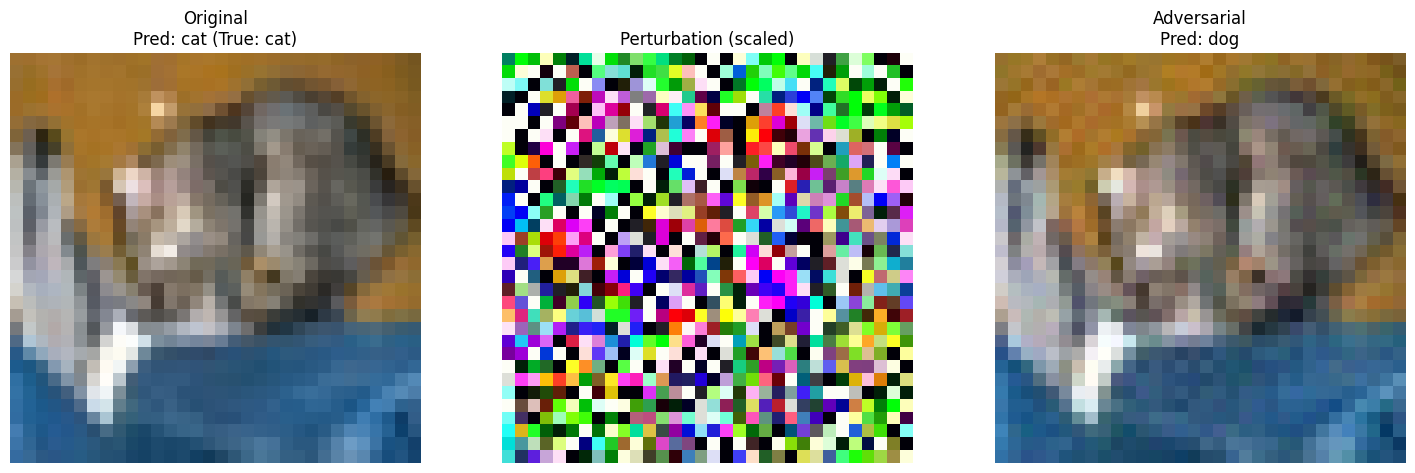


Visualizing ART PGD (Linf):
🔬 Visualizing attack: ProjectedGradientDescent
✅ Found a correctly classified image to attack.


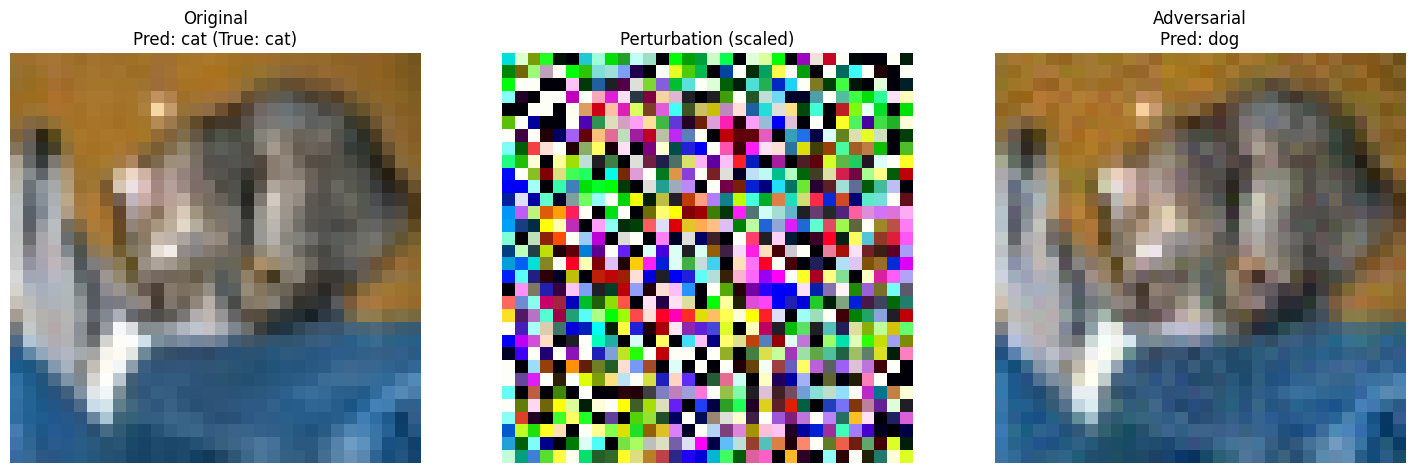

In [ ]:
# PGD (Linf) — Torch & ART
att_pgd_linf = make_attack_suite_for_model(
    base_model, criterion=criterion, device=DEVICE,
    frameworks=("torch","art"), attacks=("pgd",),
    eps=8/255, alpha=2/255, pgd_steps=20
)
Torch_PGD = att_pgd_linf["Torch PGD (Linf)"]
ART_PGD   = att_pgd_linf["ART PGD (Linf)"]

print("\nVisualizing Torch PGD (Linf):")
visualize_single_attack(base_model, test_loader, Torch_PGD, DEVICE)

print("\nVisualizing ART PGD (Linf):")
visualize_single_attack(base_model, test_loader, ART_PGD, DEVICE)


Visualizing Torch PGD (Linf):
🔬 Visualizing attack: PGD
✅ Found a correctly classified image to attack.


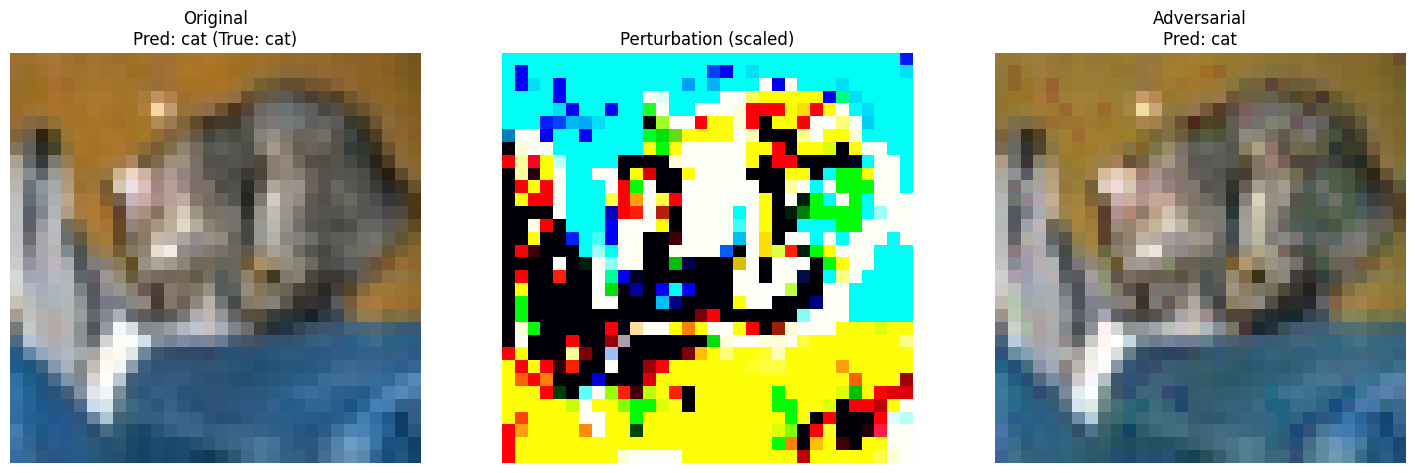


Visualizing ART PGD (Linf):
🔬 Visualizing attack: ProjectedGradientDescent
✅ Found a correctly classified image to attack.


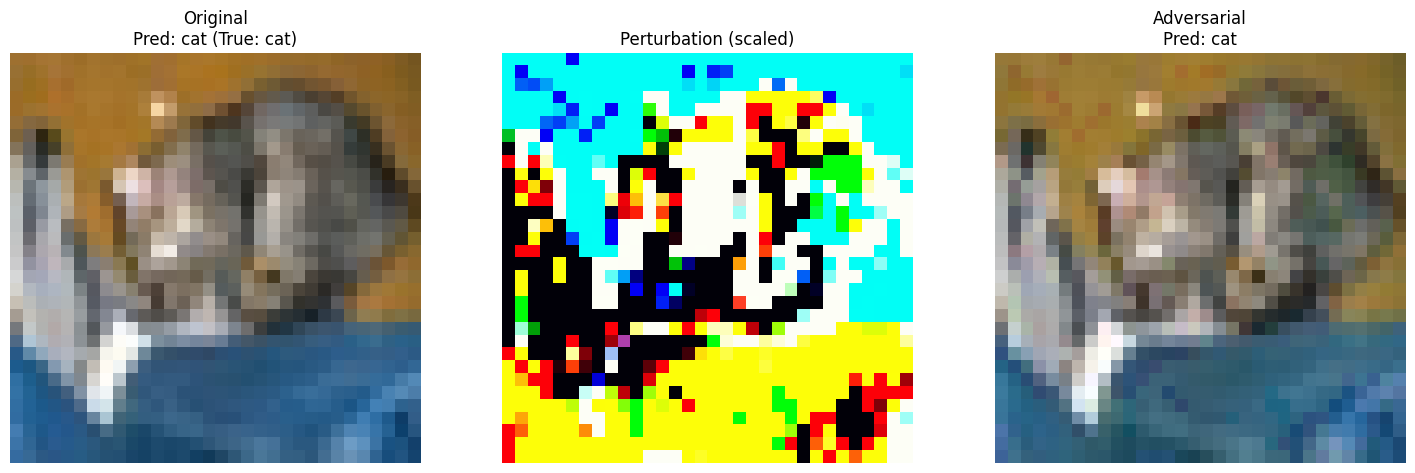

In [ ]:
# PGD (Linf) — Torch & ART
att_pgd_linf = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch","art"), attacks=("pgd",),
    eps=8/255, alpha=2/255, pgd_steps=20
)
Torch_PGD = att_pgd_linf["Torch PGD (Linf)"]
ART_PGD   = att_pgd_linf["ART PGD (Linf)"]

print("\nVisualizing Torch PGD (Linf):")
visualize_single_attack(model, test_loader, Torch_PGD, DEVICE)

print("\nVisualizing ART PGD (Linf):")
visualize_single_attack(model, test_loader, ART_PGD, DEVICE)


Visualizing Torch PGD (L2):
🔬 Visualizing attack: PGDL2
✅ Found a correctly classified image to attack.


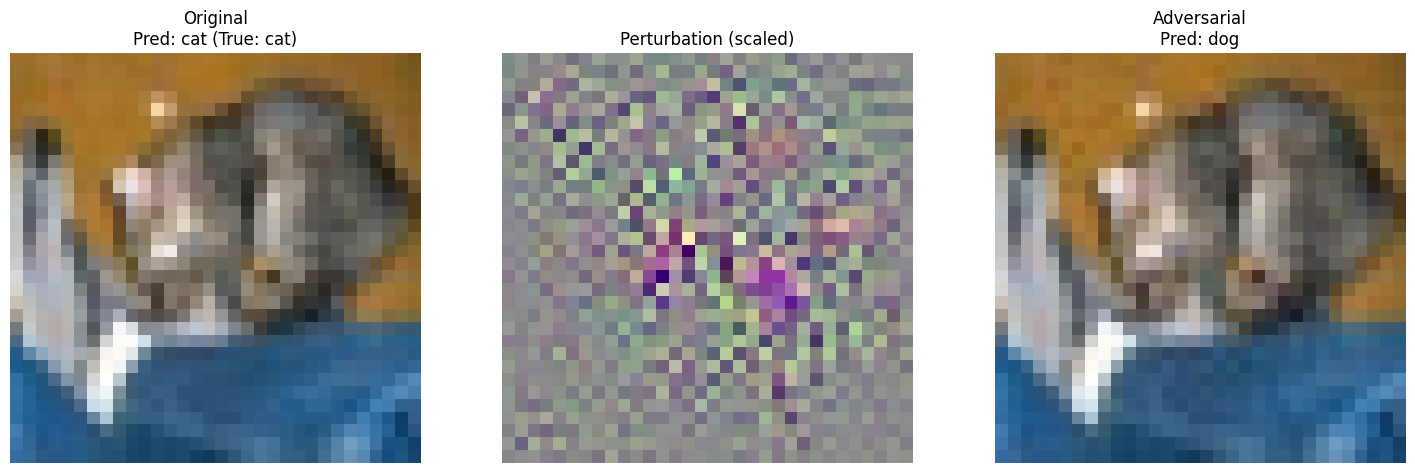


Visualizing ART PGD (L2):
🔬 Visualizing attack: ProjectedGradientDescent
✅ Found a correctly classified image to attack.


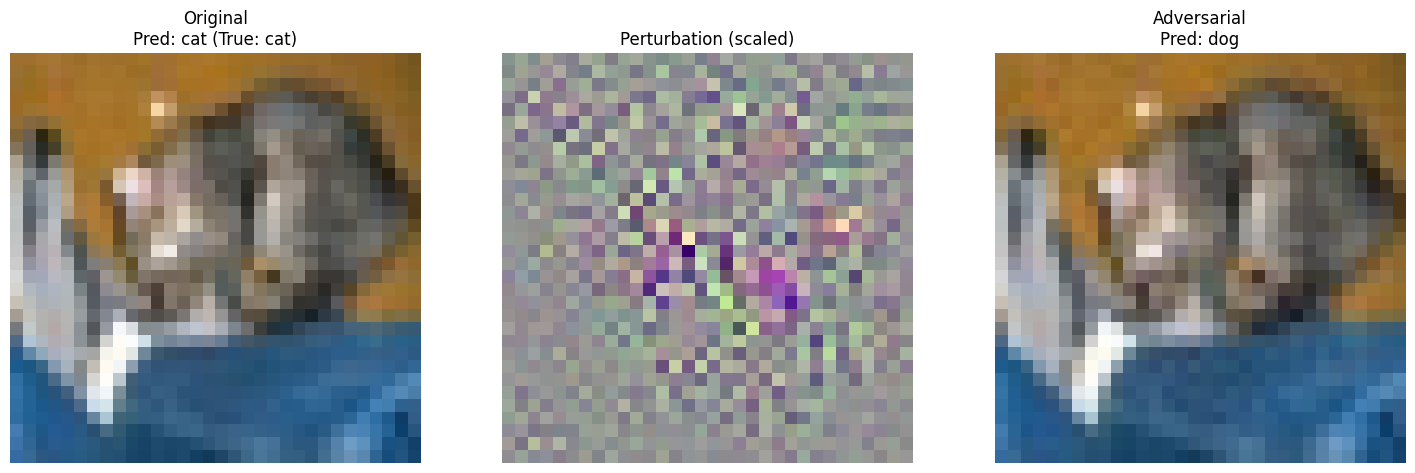

In [ ]:
# PGD (L2) — Torch & ART
att_pgd_l2 = make_attack_suite_for_model(
    base_model, criterion=criterion, device=DEVICE,
    frameworks=("torch","art"), attacks=("pgd_l2",),
    eps_l2=0.5, alpha_l2=0.1, pgd_l2_steps=20
)
Torch_PGD_L2 = att_pgd_l2["Torch PGD (L2)"]
ART_PGD_L2   = att_pgd_l2["ART PGD (L2)"]

print("\nVisualizing Torch PGD (L2):")
visualize_single_attack(base_model, test_loader, Torch_PGD_L2, DEVICE)

print("\nVisualizing ART PGD (L2):")
visualize_single_attack(base_model, test_loader, ART_PGD_L2, DEVICE)


Visualizing Torch PGD (L2):
🔬 Visualizing attack: PGDL2
✅ Found a correctly classified image to attack.


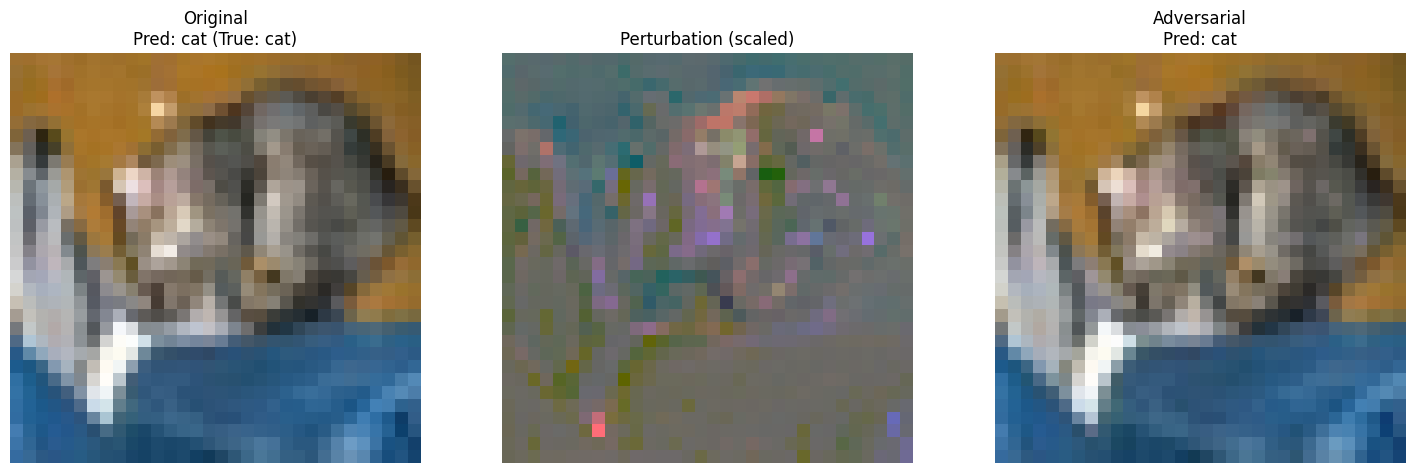


Visualizing ART PGD (L2):
🔬 Visualizing attack: ProjectedGradientDescent
✅ Found a correctly classified image to attack.


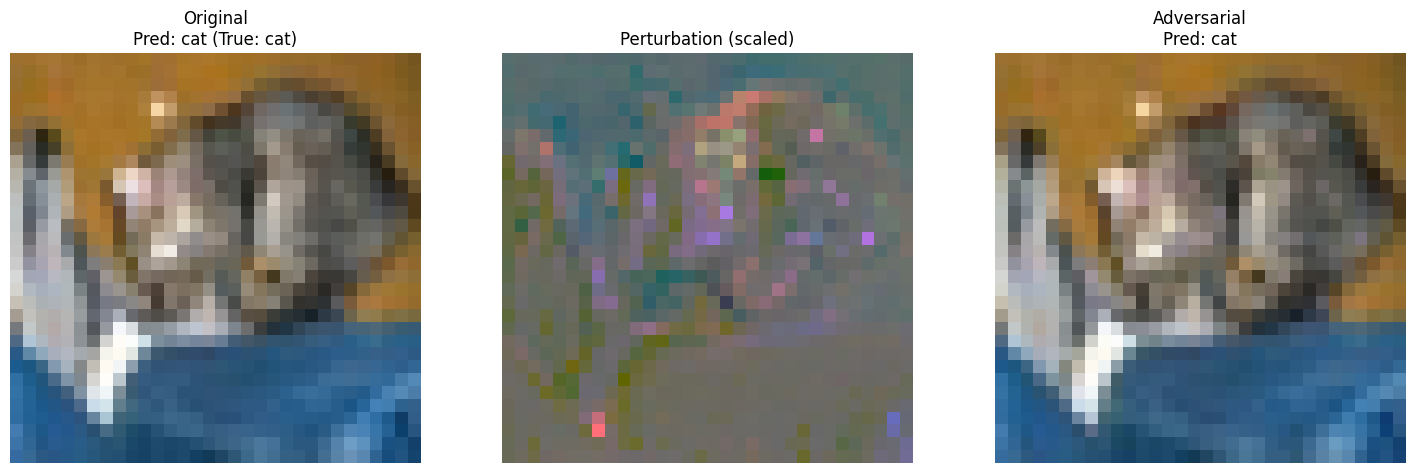

In [ ]:
# PGD (L2) — Torch & ART
att_pgd_l2 = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch","art"), attacks=("pgd_l2",),
    eps_l2=0.5, alpha_l2=0.1, pgd_l2_steps=20
)
Torch_PGD_L2 = att_pgd_l2["Torch PGD (L2)"]
ART_PGD_L2   = att_pgd_l2["ART PGD (L2)"]

print("\nVisualizing Torch PGD (L2):")
visualize_single_attack(model, test_loader, Torch_PGD_L2, DEVICE)

print("\nVisualizing ART PGD (L2):")
visualize_single_attack(model, test_loader, ART_PGD_L2, DEVICE)


Visualizing Torch FGSM (Linf):
🔬 Visualizing attack: FGSM
✅ Found a correctly classified image to attack.


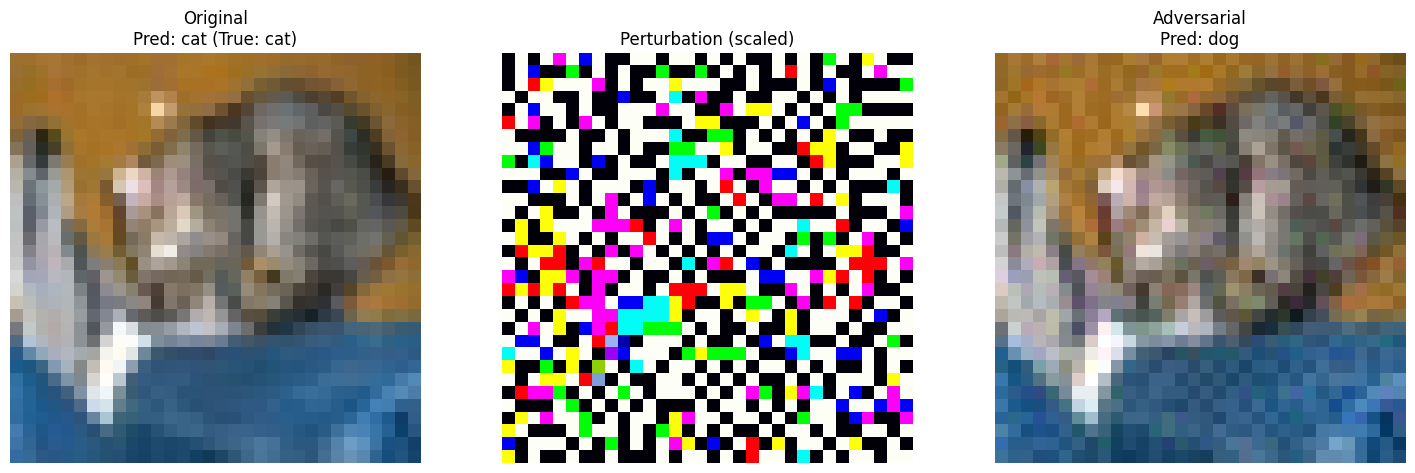


Visualizing ART FGSM (Linf):
🔬 Visualizing attack: FastGradientMethod
✅ Found a correctly classified image to attack.


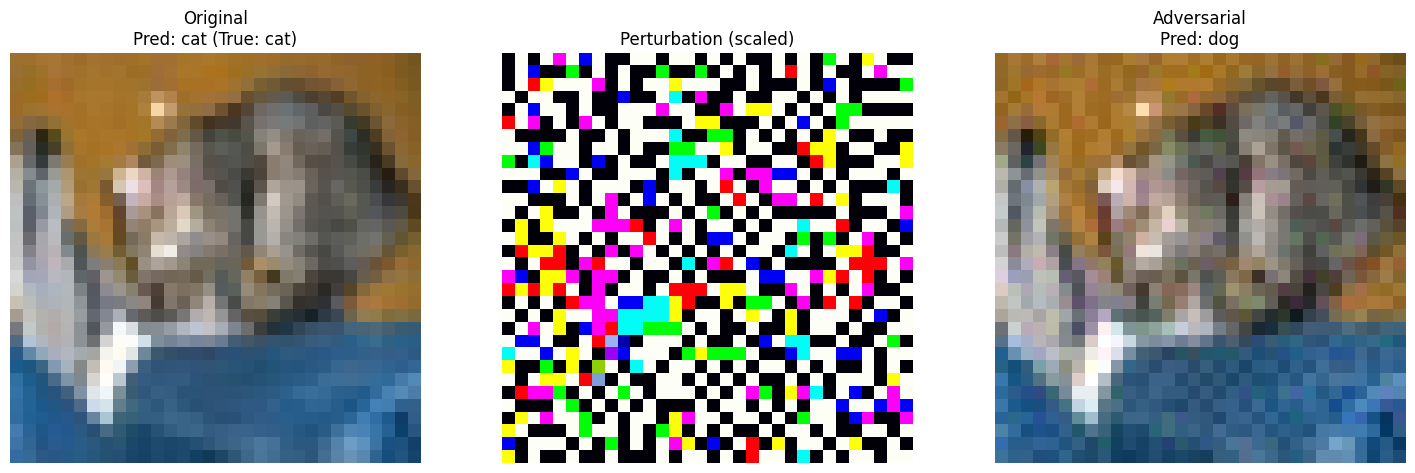

In [ ]:
# FGSM (Linf) — Torch & ART
att_fgsm = make_attack_suite_for_model(
    base_model, criterion=criterion, device=DEVICE,
    frameworks=("torch","art"), attacks=("fgsm",),
    eps=8/255
)
Torch_FGSM = att_fgsm["Torch FGSM (Linf)"]
ART_FGSM   = att_fgsm["ART FGSM (Linf)"]

print("\nVisualizing Torch FGSM (Linf):")
visualize_single_attack(base_model, test_loader, Torch_FGSM, DEVICE)

print("\nVisualizing ART FGSM (Linf):")
visualize_single_attack(base_model, test_loader, ART_FGSM, DEVICE)


Visualizing Torch FGSM (Linf):
🔬 Visualizing attack: FGSM
✅ Found a correctly classified image to attack.


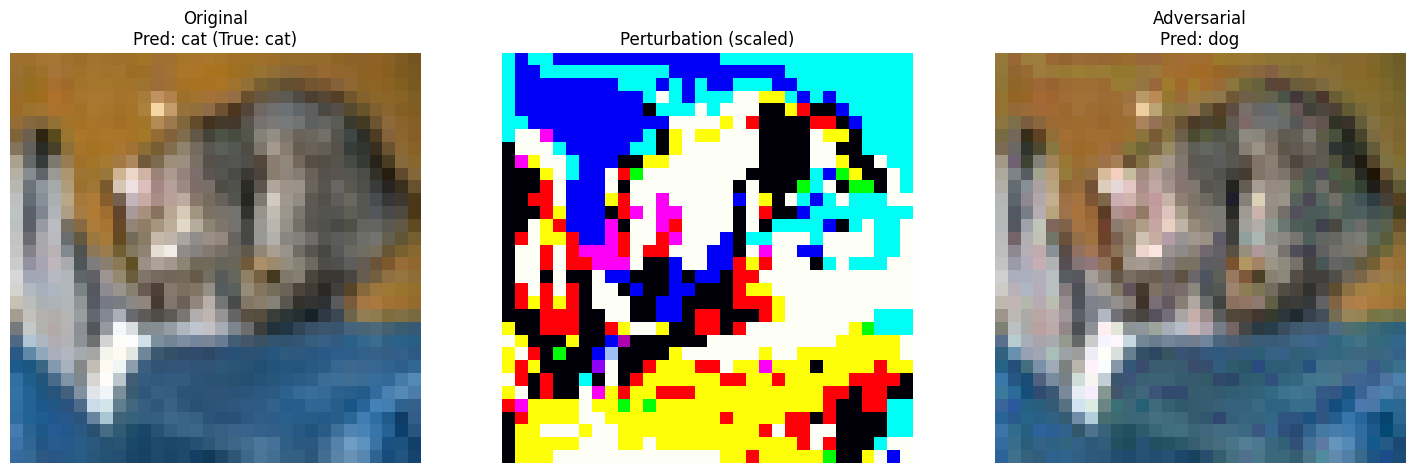


Visualizing ART FGSM (Linf):
🔬 Visualizing attack: FastGradientMethod
✅ Found a correctly classified image to attack.


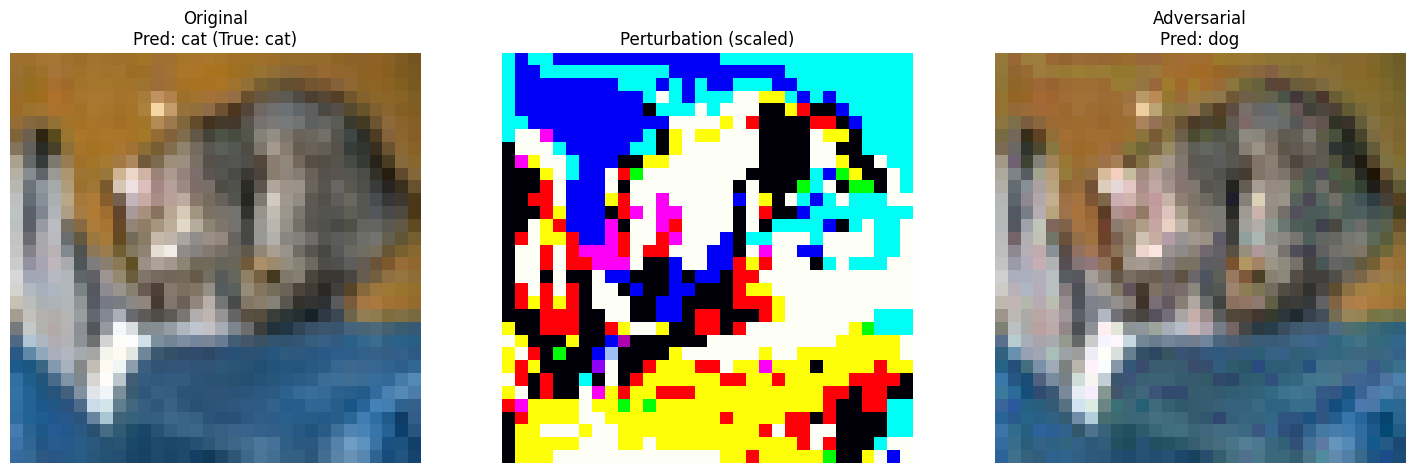

In [ ]:
# FGSM (Linf) — Torch & ART
att_fgsm = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch","art"), attacks=("fgsm",),
    eps=8/255
)
Torch_FGSM = att_fgsm["Torch FGSM (Linf)"]
ART_FGSM   = att_fgsm["ART FGSM (Linf)"]

print("\nVisualizing Torch FGSM (Linf):")
visualize_single_attack(model, test_loader, Torch_FGSM, DEVICE)

print("\nVisualizing ART FGSM (Linf):")
visualize_single_attack(model, test_loader, ART_FGSM, DEVICE)

## 6.2 AutoAttack

setting parameters for standard version

Visualizing Torch AutoAttack:
🔬 Visualizing attack: AutoAttack
✅ Found a correctly classified image to attack.


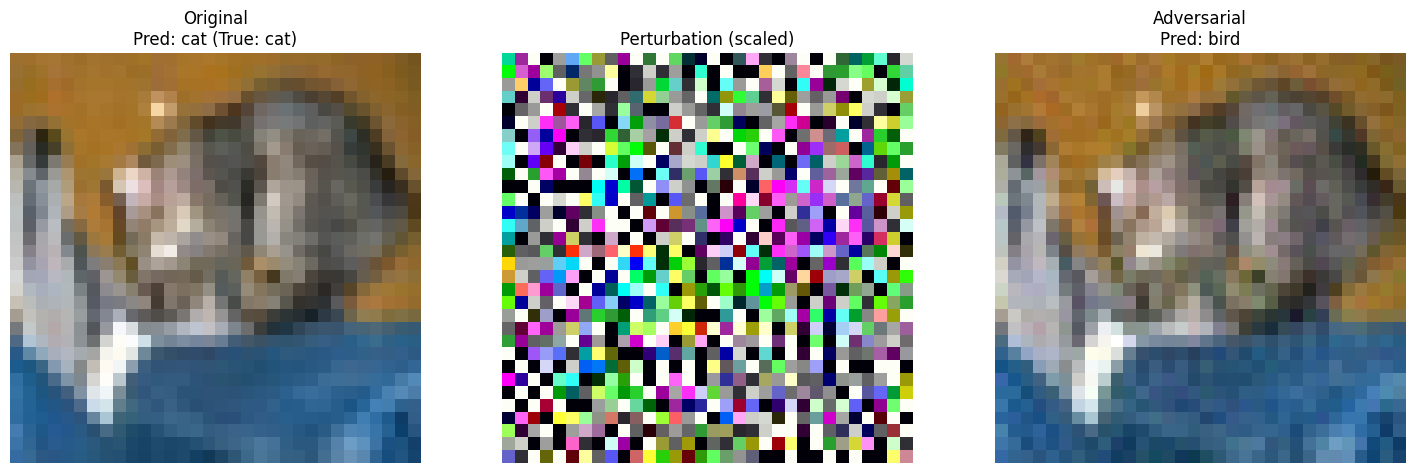


Visualizing original AutoAttack (fra31):
🔬 Visualizing attack: AutoAttack
✅ Found a correctly classified image to attack.
using standard version including apgd-ce.
initial accuracy: 100.00%
apgd-ce - 1/1 - 1 out of 1 successfully perturbed
robust accuracy after APGD-CE: 0.00% (total time 0.8 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.01961
robust accuracy: 0.00%


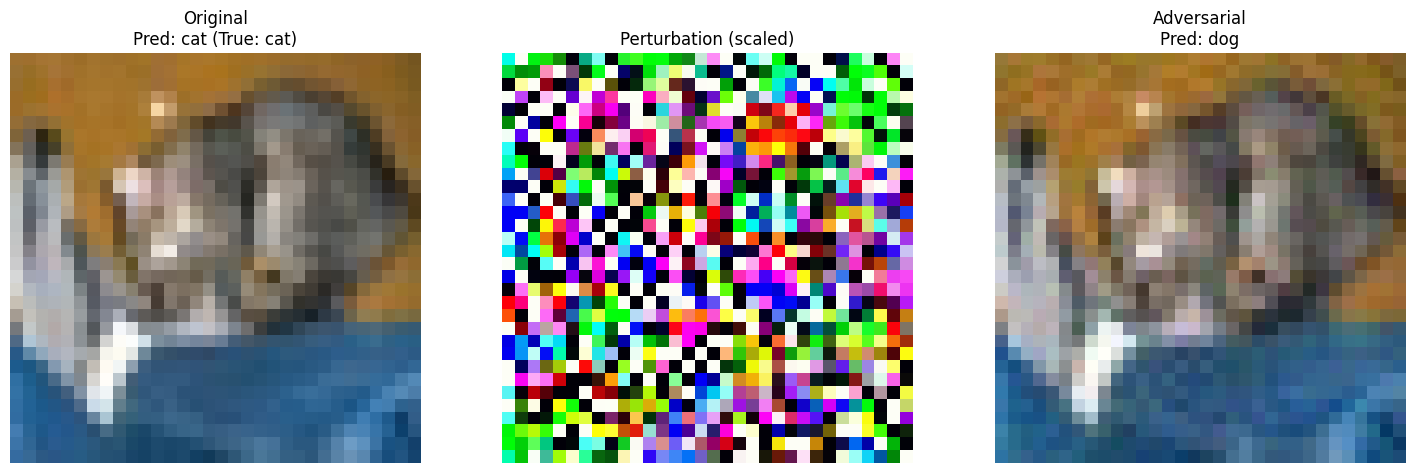


Visualizing ART AutoAttack:
🔬 Visualizing attack: AutoAttack
✅ Found a correctly classified image to attack.


AutoPGD - restart:   0%|          | 0/5 [00:00<?, ?it/s]

AutoPGD - batch:   0%|          | 0/1 [00:00<?, ?it/s]

AutoPGD - iteration:   0%|          | 0/100 [00:00<?, ?it/s]

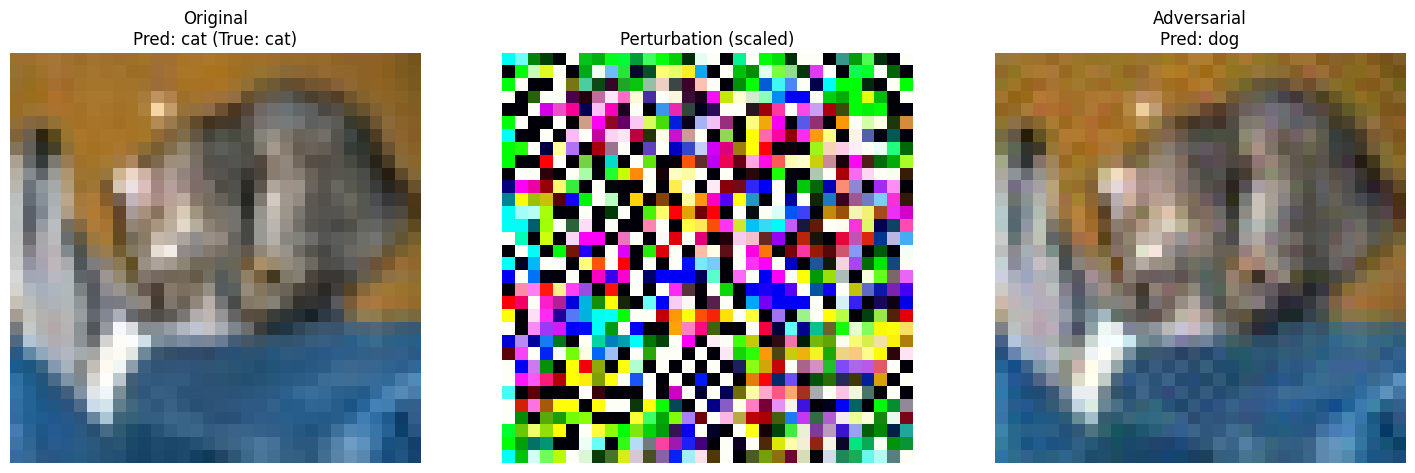

In [ ]:
# AutoAttack — Torch & Original (fra31); ART variant optional
att_aa = make_attack_suite_for_model(
    base_model, criterion=criterion, device=DEVICE,
    frameworks=("torch","aa_orig","art"), attacks=("autoattack",),
    eps=8/255
)
Torch_AA = att_aa["Torch AutoAttack (std)"]
AA_ORIG  = att_aa["AutoAttack (orig)"]        # requires generate_adv to handle AutoAttackOriginal
ART_AA   = att_aa["ART AutoAttack (std)"]

# (speed-up) run only APGD-CE for viz
AA_ORIG.attacks_to_run = ["apgd-ce"]

print("\nVisualizing Torch AutoAttack:")
visualize_single_attack(base_model, test_loader, Torch_AA, DEVICE)

print("\nVisualizing original AutoAttack (fra31):")
visualize_single_attack(base_model, test_loader, AA_ORIG, DEVICE)

print("\nVisualizing ART AutoAttack:")
visualize_single_attack(base_model, test_loader, ART_AA, DEVICE)

setting parameters for standard version

Visualizing Torch AutoAttack:
🔬 Visualizing attack: AutoAttack
✅ Found a correctly classified image to attack.


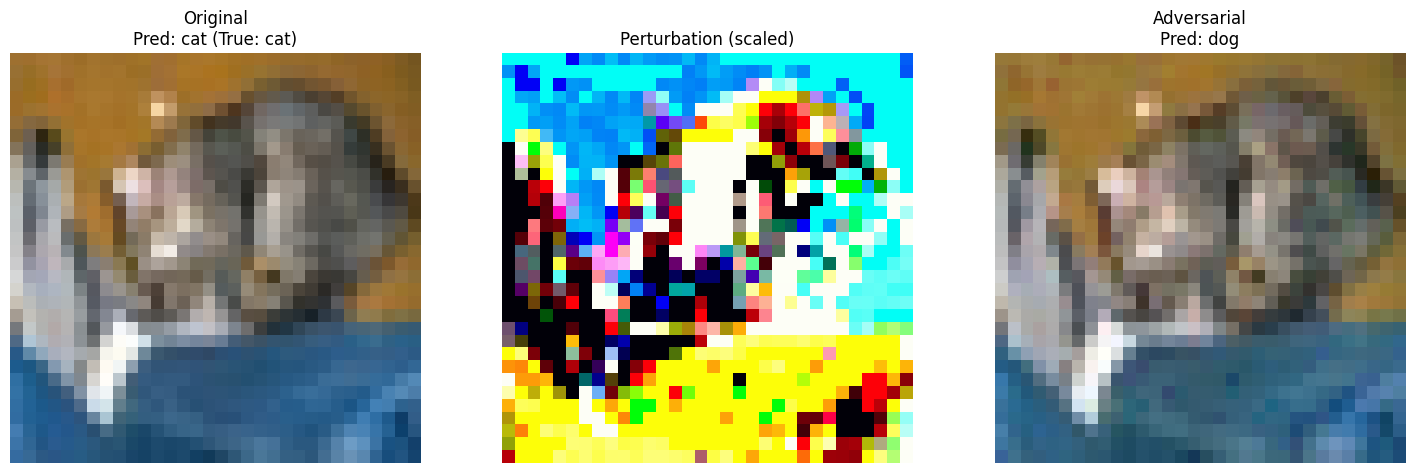


Visualizing original AutoAttack (fra31):
🔬 Visualizing attack: AutoAttack
✅ Found a correctly classified image to attack.
using standard version including apgd-ce.
initial accuracy: 100.00%
apgd-ce - 1/1 - 1 out of 1 successfully perturbed
robust accuracy after APGD-CE: 0.00% (total time 0.7 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.01961
robust accuracy: 0.00%


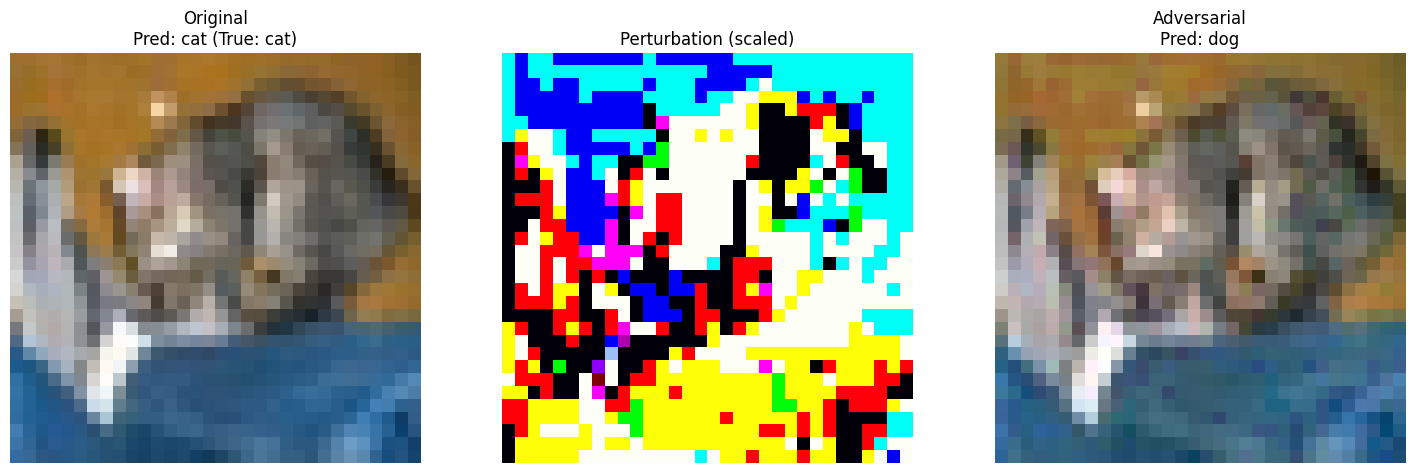


Visualizing ART AutoAttack:
🔬 Visualizing attack: AutoAttack
✅ Found a correctly classified image to attack.


AutoPGD - restart:   0%|          | 0/5 [00:00<?, ?it/s]

AutoPGD - batch:   0%|          | 0/1 [00:00<?, ?it/s]

AutoPGD - iteration:   0%|          | 0/100 [00:00<?, ?it/s]

AutoPGD - batch:   0%|          | 0/1 [00:00<?, ?it/s]

AutoPGD - iteration:   0%|          | 0/100 [00:00<?, ?it/s]

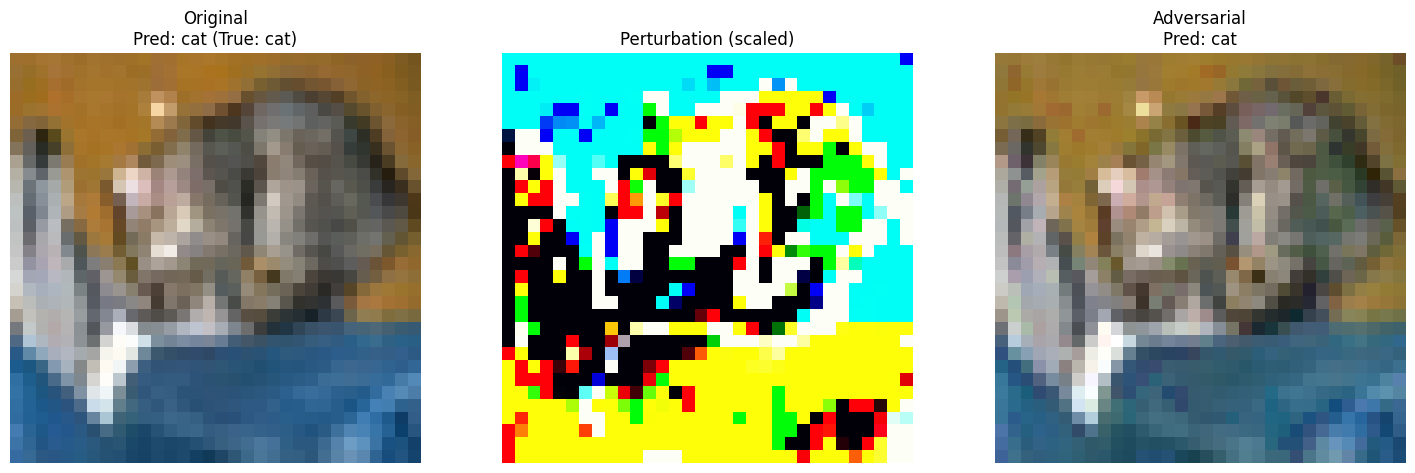

In [ ]:
# AutoAttack — Torch & Original (fra31); ART variant optional
att_aa = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch","aa_orig","art"), attacks=("autoattack",),
    eps=8/255
)
Torch_AA = att_aa["Torch AutoAttack (std)"]
AA_ORIG  = att_aa["AutoAttack (orig)"]        # requires generate_adv to handle AutoAttackOriginal
ART_AA   = att_aa["ART AutoAttack (std)"]

# (speed-up) run only APGD-CE for viz
AA_ORIG.attacks_to_run = ["apgd-ce"]

print("\nVisualizing Torch AutoAttack:")
visualize_single_attack(model, test_loader, Torch_AA, DEVICE)

print("\nVisualizing original AutoAttack (fra31):")
visualize_single_attack(model, test_loader, AA_ORIG, DEVICE)

print("\nVisualizing ART AutoAttack:")
visualize_single_attack(model, test_loader, ART_AA, DEVICE)

## 6.3 CW

In [ ]:
# CW (L2) — Torch & ART
att_cw = make_attack_suite_for_model(
    base_model, criterion=criterion, device=DEVICE,
    frameworks=("torch","art"), attacks=("cw",),
    cw_steps=200, cw_lr=0.01
)
Torch_CW = att_cw["Torch CW (L2)"]
ART_CW   = att_cw["ART CW (L2)"]

print("\nVisualizing Torch CW (L2):")
visualize_single_attack(base_model, test_loader, Torch_CW, DEVICE)

print("\nVisualizing ART CW (L2):")
visualize_single_attack(base_model, test_loader, ART_CW, DEVICE)


Visualizing Torch CW (L2):
🔬 Visualizing attack: CW
✅ Found a correctly classified image to attack.


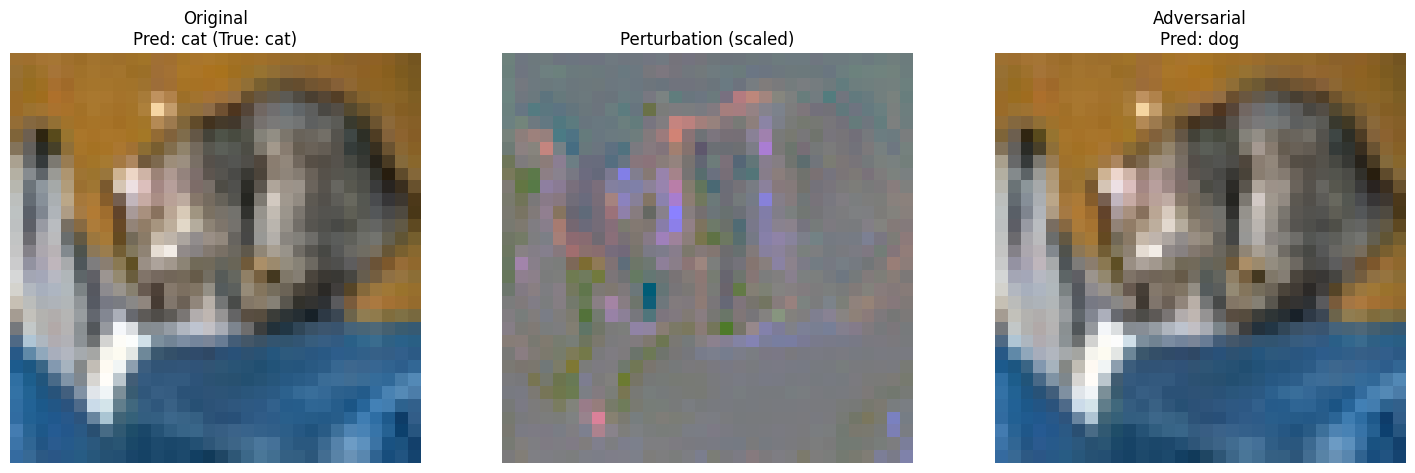


Visualizing ART CW (L2):
🔬 Visualizing attack: CarliniL2Method
✅ Found a correctly classified image to attack.


C&W L_2:   0%|          | 0/1 [00:00<?, ?it/s]

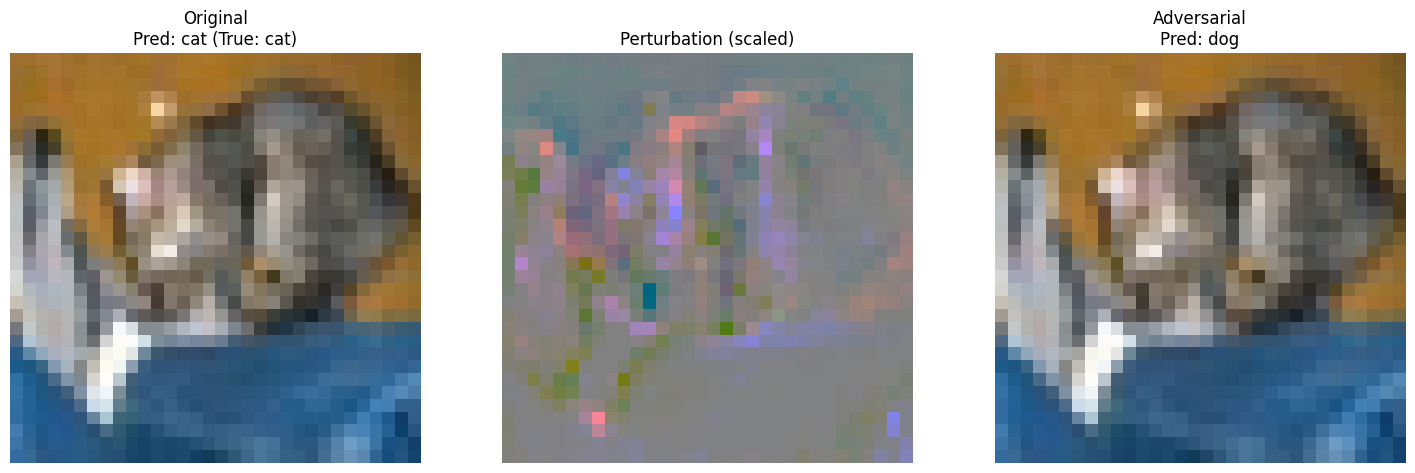

In [ ]:
# CW (L2) — Torch & ART
att_cw = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch","art"), attacks=("cw",),
    cw_steps=200, cw_lr=0.01
)
Torch_CW = att_cw["Torch CW (L2)"]
ART_CW   = att_cw["ART CW (L2)"]

print("\nVisualizing Torch CW (L2):")
visualize_single_attack(model, test_loader, Torch_CW, DEVICE)

print("\nVisualizing ART CW (L2):")
visualize_single_attack(model, test_loader, ART_CW, DEVICE)

## 6.4 DeepFool


Visualizing Torch DeepFool (L2):
🔬 Visualizing attack: DeepFool
✅ Found a correctly classified image to attack.


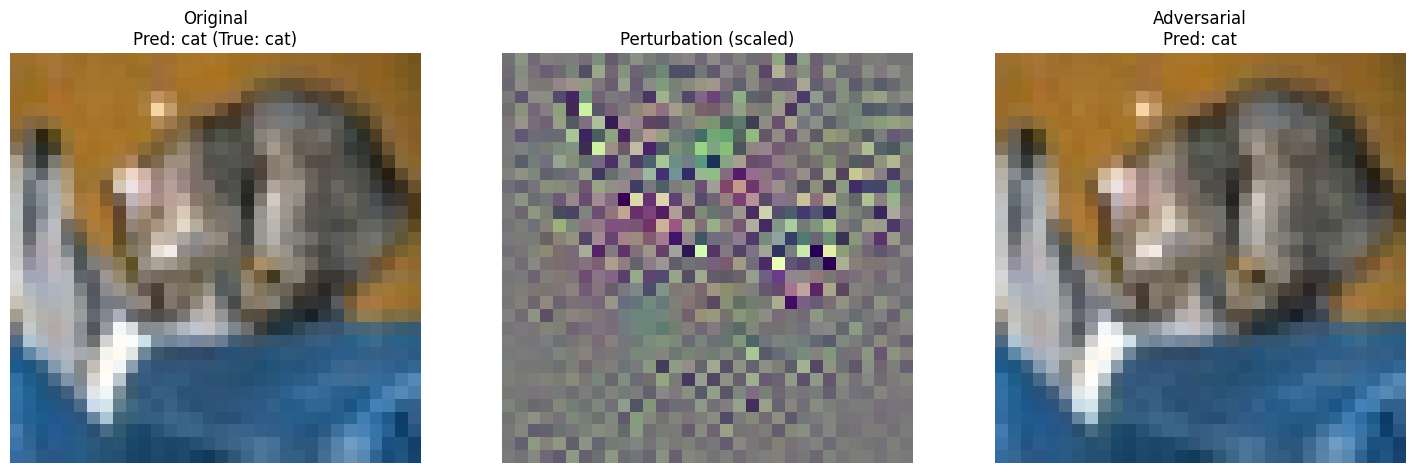


Visualizing ART DeepFool (L2):
🔬 Visualizing attack: DeepFool
✅ Found a correctly classified image to attack.


DeepFool:   0%|          | 0/1 [00:00<?, ?it/s]

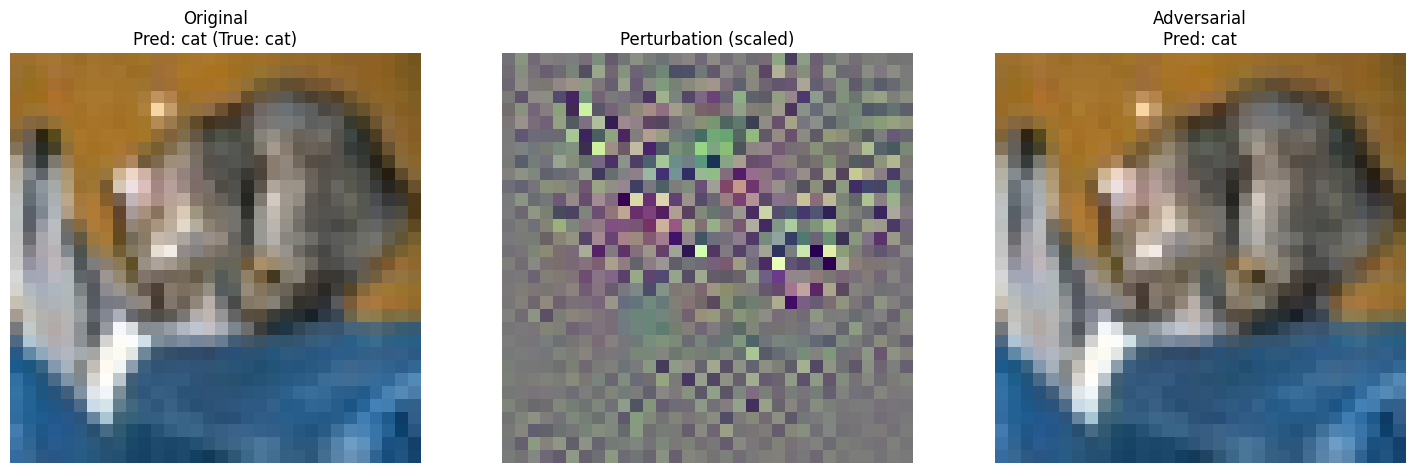

In [ ]:
# DeepFool (L2) — Torch & ART
att_df = make_attack_suite_for_model(
    base_model, criterion=criterion, device=DEVICE,
    frameworks=("torch","art"), attacks=("deepfool",),
    df_steps=50
)
Torch_DF = att_df["Torch DeepFool (L2)"]
ART_DF   = att_df["ART DeepFool (L2)"]

print("\nVisualizing Torch DeepFool (L2):")
visualize_single_attack(base_model, test_loader, Torch_DF, DEVICE)

print("\nVisualizing ART DeepFool (L2):")
visualize_single_attack(base_model, test_loader, ART_DF, DEVICE)


Visualizing Torch DeepFool (L2):
🔬 Visualizing attack: DeepFool
✅ Found a correctly classified image to attack.


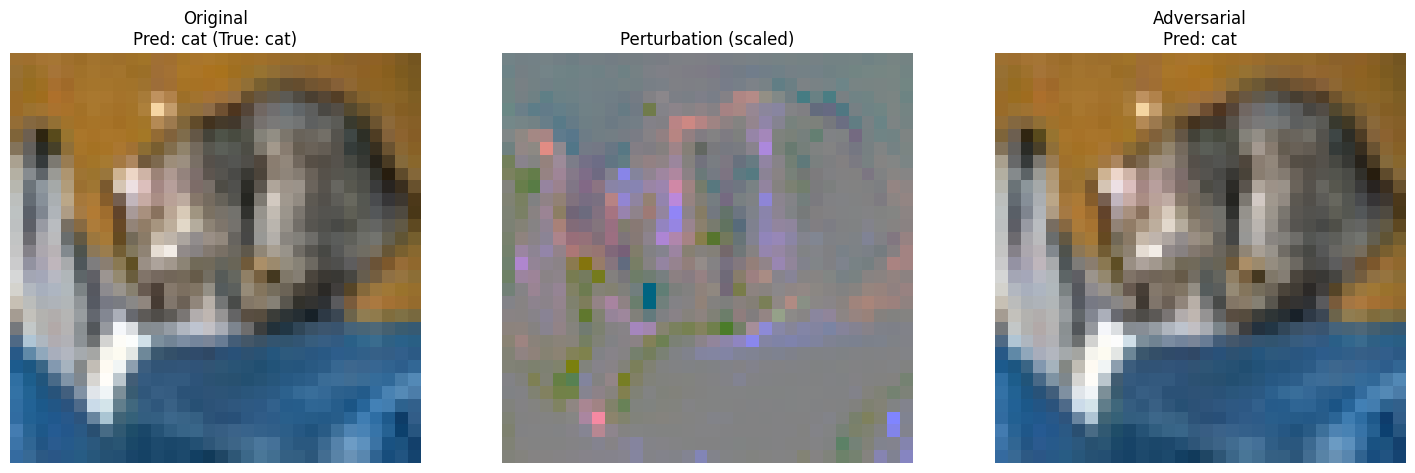


Visualizing ART DeepFool (L2):
🔬 Visualizing attack: DeepFool
✅ Found a correctly classified image to attack.


DeepFool:   0%|          | 0/1 [00:00<?, ?it/s]

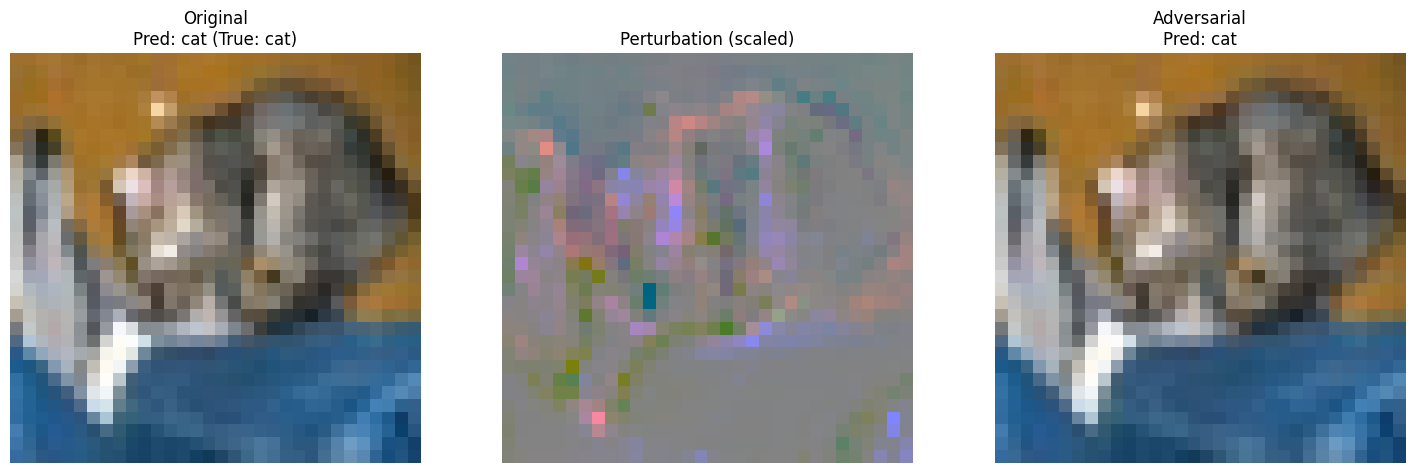

In [ ]:
# DeepFool (L2) — Torch & ART
att_df = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch","art"), attacks=("deepfool",),
    df_steps=50
)
Torch_DF = att_df["Torch DeepFool (L2)"]
ART_DF   = att_df["ART DeepFool (L2)"]

print("\nVisualizing Torch DeepFool (L2):")
visualize_single_attack(model, test_loader, Torch_DF, DEVICE)

print("\nVisualizing ART DeepFool (L2):")
visualize_single_attack(model, test_loader, ART_DF, DEVICE)

In [ ]:

import os
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F


def pgd_step_sweep(
    model,
    *,
    test_loader,
    device,
    criterion,
    run_root,
    steps_list=(1, 2, 5, 10, 20, 50, 100),
    eps=8/255,
    alpha=2/255,
    restarts=1,
    use_amp=True,
    include_l2=False,
    eps_l2=0.5,
    alpha_l2=0.1,
):
    rows = []

    for steps in steps_list:
        run_dir = os.path.join(run_root, f"pgd_sweep_steps_{steps}")
        ev = Evaluator(model=model, test_loader=test_loader, device=device, run_dir=run_dir, use_amp=use_amp)

        attacks = ["pgd"]
        if include_l2:
            attacks.append("pgd_l2")

        suite = make_attack_suite_for_model(
            model, criterion=criterion, device=device,
            frameworks=("torch",),             # use torchattacks versions for PGD
            attacks=tuple(attacks),
            eps=eps, alpha=alpha,
            pgd_steps=steps, pgd_restarts=restarts,
            eps_l2=eps_l2, alpha_l2=alpha_l2,
            pgd_l2_steps=steps,
        )

        results = ev.run(attacks_dict=suite)

        # your Evaluator stores accuracy in percent
        clean_acc = results["Clean (No Attack)"]["acc"]
        linf_key = "Torch PGD (Linf)"
        linf_acc = results[linf_key]["acc"] if linf_key in results else None

        row = {
            "steps": steps,
            "clean_acc": clean_acc,
            "pgd_linf_acc": linf_acc,
        }

        if include_l2:
            l2_key = "Torch PGD (L2)"
            row["pgd_l2_acc"] = results[l2_key]["acc"] if l2_key in results else None

        rows.append(row)

    df = pd.DataFrame(rows).sort_values("steps").reset_index(drop=True)
    return df





In [ ]:
# --- Example: run sweeps for baseline vs robust ---
EVAL_SWEEP_ROOT = os.path.join(EVAL_BASE_DIR, "pgd_step_sweeps")

df_base = pgd_step_sweep(
    base_model,
    test_loader=test_loader, device=DEVICE, criterion=criterion,
    run_root=os.path.join(EVAL_SWEEP_ROOT, "ta100"),
    steps_list=(1, 2, 5, 10, 20, 50, 100),
    eps=8/255, alpha=2/255,
    restarts=5,               # worst-of-5
    include_l2=True,
    eps_l2=0.5, alpha_l2=0.1
)



🔬 Running: Clean (No Attack)...


Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.5621, Accuracy: 82.51%
🔬 Running: Torch PGD (Linf)...


Eval [Torch PGD (Linf)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (Linf). Avg Loss: 0.7192, Accuracy: 75.72%
🔬 Running: Torch PGD (L2)...


...

✅ Finished Clean (No Attack). Avg Loss: 0.5621, Accuracy: 82.51%
🔬 Running: Torch PGD (Linf)...


Eval [Torch PGD (Linf)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (Linf). Avg Loss: 1.4902, Accuracy: 47.82%
🔬 Running: Torch PGD (L2)...


Eval [Torch PGD (L2)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (L2). Avg Loss: 1.1154, Accuracy: 59.08%

💾 Results saved to /content/eval/pgd_step_sweeps/ta100/pgd_sweep_steps_100/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                     loss     acc
Clean (No Attack)  0.5621  82.51%
Torch PGD (Linf)   1.4902  47.82%
Torch PGD (L2)     1.1154  59.08%
---------------------------------------



In [ ]:

df_rob = pgd_step_sweep(
    model,
    test_loader=test_loader, device=DEVICE, criterion=criterion,
    run_root=os.path.join(EVAL_SWEEP_ROOT, "robust"),
    steps_list=(1, 2, 5, 10, 20, 50, 100),
    eps=8/255, alpha=2/255,
    restarts=5,
    include_l2=True,
    eps_l2=0.5, alpha_l2=0.1
)

display(df_base)
display(df_rob)

🔬 Running: Clean (No Attack)...


Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.5379, Accuracy: 82.93%
🔬 Running: Torch PGD (Linf)...


Eval [Torch PGD (Linf)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (Linf). Avg Loss: 0.6970, Accuracy: 75.61%
🔬 Running: Torch PGD (L2)...


...

✅ Finished Torch PGD (Linf). Avg Loss: 1.5004, Accuracy: 47.89%
🔬 Running: Torch PGD (L2)...


Eval [Torch PGD (L2)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (L2). Avg Loss: 1.0965, Accuracy: 59.90%

💾 Results saved to /content/eval/pgd_step_sweeps/robust/pgd_sweep_steps_100/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                     loss     acc
Clean (No Attack)  0.5379  82.93%
Torch PGD (Linf)   1.5004  47.89%
Torch PGD (L2)     1.0965  59.90%
---------------------------------------



,steps,clean_acc,pgd_linf_acc,pgd_l2_acc
0,1,82.51,75.72,78.95
1,2,82.51,69.85,75.34
2,5,82.51,55.47,64.89
3,10,82.51,49.22,60.99
4,20,82.51,48.01,59.60
5,50,82.51,47.84,59.22
6,100,82.51,47.82,59.08


,steps,clean_acc,pgd_linf_acc,pgd_l2_acc
0,1,82.93,75.61,79.52
1,2,82.93,69.87,75.53
2,5,82.93,55.79,65.30
3,10,82.93,49.29,61.87
4,20,82.93,48.23,60.46
5,50,82.93,47.94,59.97
6,100,82.93,47.89,59.90


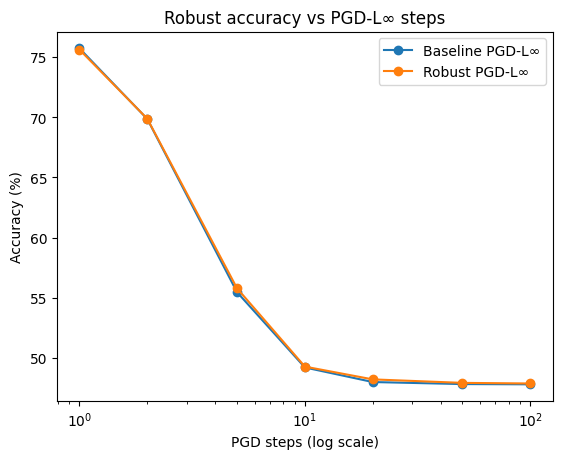

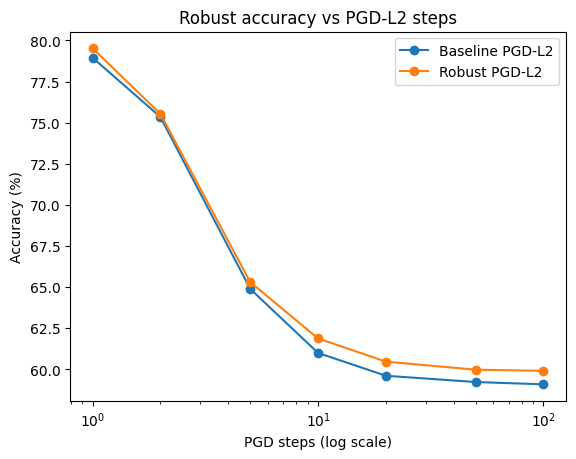

In [ ]:

# --- Plot (no manual colors) ---
plt.figure()
plt.plot(df_base["steps"], df_base["pgd_linf_acc"], marker="o", label="Baseline PGD-L∞")
plt.plot(df_rob["steps"],  df_rob["pgd_linf_acc"],  marker="o", label="Robust PGD-L∞")
plt.xscale("log")
plt.xlabel("PGD steps (log scale)")
plt.ylabel("Accuracy (%)")
plt.title("Robust accuracy vs PGD-L∞ steps")
plt.legend()
plt.show()

plt.figure()
plt.plot(df_base["steps"], df_base["pgd_l2_acc"], marker="o", label="Baseline PGD-L2")
plt.plot(df_rob["steps"],  df_rob["pgd_l2_acc"],  marker="o", label="Robust PGD-L2")
plt.xscale("log")
plt.xlabel("PGD steps (log scale)")
plt.ylabel("Accuracy (%)")
plt.title("Robust accuracy vs PGD-L2 steps")
plt.legend()
plt.show()

In [ ]:
# --- Example: run sweeps for baseline vs robust ---
EVAL_SWEEP_ROOT = os.path.join(EVAL_BASE_DIR, "pgd_step_sweeps")

df_base = pgd_step_sweep(
    base_model,
    test_loader=test_loader, device=DEVICE, criterion=criterion,
    run_root=os.path.join(EVAL_SWEEP_ROOT, "baseline"),
    steps_list=(1, 2, 5, 10, 20, 50, 100),
    eps=8/255, alpha=2/255,
    restarts=5,               # worst-of-5
    include_l2=True,
    eps_l2=0.5, alpha_l2=0.1
)



🔬 Running: Clean (No Attack)...


Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.2490, Accuracy: 92.00%
🔬 Running: Torch PGD (Linf)...


Eval [Torch PGD (Linf)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (Linf). Avg Loss: 6.9138, Accuracy: 9.78%
🔬 Running: Torch PGD (L2)...


...

✅ Finished Clean (No Attack). Avg Loss: 0.2490, Accuracy: 92.00%
🔬 Running: Torch PGD (Linf)...


Eval [Torch PGD (Linf)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (Linf). Avg Loss: 28.9257, Accuracy: 0.00%
🔬 Running: Torch PGD (L2)...


Eval [Torch PGD (L2)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (L2). Avg Loss: 20.6943, Accuracy: 0.00%

💾 Results saved to /content/eval/pgd_step_sweeps/baseline/pgd_sweep_steps_100/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                      loss     acc
Clean (No Attack)   0.2490  92.00%
Torch PGD (Linf)   28.9257   0.00%
Torch PGD (L2)     20.6943   0.00%
---------------------------------------



In [ ]:
display(df_base)


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def accuracy_vs_eps_linf(
    model,
    *,
    test_loader,
    device,
    criterion,
    run_root,
    eps_list=(0, 1/255, 2/255, 4/255, 6/255, 8/255, 10/255, 12/255, 16/255),
    # PGD params
    pgd_steps=50,
    pgd_alpha=None,          # if None, uses eps/4 (common heuristic)
    pgd_restarts=1,
    # which attacks to include
    include_pgd=True,
    include_autoattack=True,
    aa_version="standard",
    use_amp=True,
):
    os.makedirs(run_root, exist_ok=True)
    rows = []

    for eps in eps_list:
        # choose step size
        alpha = (eps / 4) if (pgd_alpha is None) else pgd_alpha
        # avoid alpha=0 when eps=0
        if eps == 0:
            alpha = 0.0

        run_dir = os.path.join(run_root, f"eps_{eps:.8f}".replace(".", "p"))
        ev = Evaluator(model=model, test_loader=test_loader, device=device, run_dir=run_dir, use_amp=use_amp)

        attacks = []
        frameworks = []

        # Always compute clean
        # Evaluator.run() will include "Clean (No Attack)" automatically in your notebook.
        if include_pgd:
            attacks.append("pgd")
            frameworks.append("torch")

        if include_autoattack and eps > 0:
            attacks.append("autoattack")
            frameworks.append("aa_orig")   # matches your key "AutoAttack (orig)"

        suite = make_attack_suite_for_model(
            model,
            criterion=criterion,
            device=device,
            frameworks=tuple(set(frameworks)) if frameworks else ("torch",),
            attacks=tuple(attacks) if attacks else tuple(),
            eps=float(eps),
            alpha=float(alpha),
            pgd_steps=int(pgd_steps),
            pgd_restarts=int(pgd_restarts),
            aa_version=aa_version,
        )

        results = ev.run(attacks_dict=suite)

        row = {
            "eps": float(eps),
            "clean_acc": results["Clean (No Attack)"]["acc"],
        }

        if include_pgd and "Torch PGD (Linf)" in results:
            row["pgd_linf_acc"] = results["Torch PGD (Linf)"]["acc"]
        else:
            row["pgd_linf_acc"] = None

        if include_autoattack and eps > 0 and "AutoAttack (orig)" in results:
            row["aa_linf_acc"] = results["AutoAttack (orig)"]["acc"]
        else:
            row["aa_linf_acc"] = None

        rows.append(row)

    df = pd.DataFrame(rows).sort_values("eps").reset_index(drop=True)
    return df


def plot_accuracy_vs_eps(df, *, title="Accuracy vs ε (ℓ∞)"):
    x = df["eps"].values

    plt.figure()
    plt.plot(x, df["clean_acc"].values, marker="o", label="Clean")
    if "pgd_linf_acc" in df.columns:
        plt.plot(x, df["pgd_linf_acc"].values, marker="o", label="PGD-ℓ∞")
    if "aa_linf_acc" in df.columns:
        plt.plot(x, df["aa_linf_acc"].values, marker="o", label="AutoAttack-ℓ∞")

    plt.xlabel("ε (L∞ budget, in [0,1] pixel scale)")
    plt.ylabel("Accuracy (%)")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.5)
    plt.show()


In [ ]:
EVAL_EPS_ROOT = os.path.join(EVAL_BASE_DIR, "eps_sweeps_linf")
eps_list = (0, 5/255, 10/255, 15/255, 20/255, 25/255, 30/255)

df_base_eps = accuracy_vs_eps_linf(
    base_model,
    test_loader=test_loader, device=DEVICE, criterion=criterion,
    run_root=os.path.join(EVAL_EPS_ROOT, "baseline"),
    eps_list=eps_list,
    pgd_steps=20, pgd_restarts=5,
    include_pgd=True, include_autoattack=False,
)


display(df_base_eps)

plot_accuracy_vs_eps(df_base_eps, title="Baseline: Accuracy vs ε (ℓ∞)")


🔬 Running: Clean (No Attack)...


Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.2490, Accuracy: 92.00%
🔬 Running: Torch PGD (Linf)...


Eval [Torch PGD (Linf)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (Linf). Avg Loss: 0.2490, Accuracy: 92.00%

💾 Results saved to /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_linf/baseline/eps_0p00000000/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                     loss     acc
Clean (No Attack)  0.2490  92.00%
Torch PGD (Linf)   0.2490  92.00%
---------------------------------------

🔬 Running: Clean (No Attack)...


Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.2490, Accuracy: 92.00%
🔬 Running: Torch PGD (Linf)...


Eval [Torch PGD (Linf)]:   0%|          | 0/79 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:

df_ta50_eps = accuracy_vs_eps_linf(
    model,
    test_loader=test_loader, device=DEVICE, criterion=criterion,
    run_root=os.path.join(EVAL_EPS_ROOT, "ta50"),
    eps_list=eps_list,
    pgd_steps=20, pgd_restarts=5,
    include_pgd=True, include_autoattack=False,
)
display(df_ta50_eps)

plot_accuracy_vs_eps(df_ta50_eps,  title="Robust ta50: Accuracy vs ε (ℓ∞)")



In [ ]:

df_ta100_eps = accuracy_vs_eps_linf(
    model1,
    test_loader=test_loader, device=DEVICE, criterion=criterion,
    run_root=os.path.join(EVAL_EPS_ROOT, "ta100"),
    eps_list=eps_list,
    pgd_steps=20, pgd_restarts=5,
    include_pgd=True, include_autoattack=False,
)
display(df_ta100_eps)

plot_accuracy_vs_eps(df_ta100_eps,  title="Robust ta100: Accuracy vs ε (ℓ∞)")



🔬 Running: Clean (No Attack)...


Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.2490, Accuracy: 92.00%
🔬 Running: Torch PGD (Linf)...


Eval [Torch PGD (Linf)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (Linf). Avg Loss: 0.2490, Accuracy: 92.00%

💾 Results saved to /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_linf/baseline/eps_0p00000000/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                     loss     acc
Clean (No Attack)  0.2490  92.00%
Torch PGD (Linf)   0.2490  92.00%
---------------------------------------

🔬 Running: Clean (No Attack)...


...

Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.2490, Accuracy: 92.00%
🔬 Running: Torch PGD (Linf)...


Eval [Torch PGD (Linf)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (Linf). Avg Loss: 33.4287, Accuracy: 0.00%

💾 Results saved to /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_linf/baseline/eps_0p11764706/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                      loss     acc
Clean (No Attack)   0.2490  92.00%
Torch PGD (Linf)   33.4287   0.00%
---------------------------------------



,eps,clean_acc,pgd_linf_acc,aa_linf_acc
0,0.000000,92.0,92.0,None
1,0.019608,92.0,0.0,None
2,0.039216,92.0,0.0,None
3,0.058824,92.0,0.0,None
4,0.078431,92.0,0.0,None
5,0.098039,92.0,0.0,None
6,0.117647,92.0,0.0,None


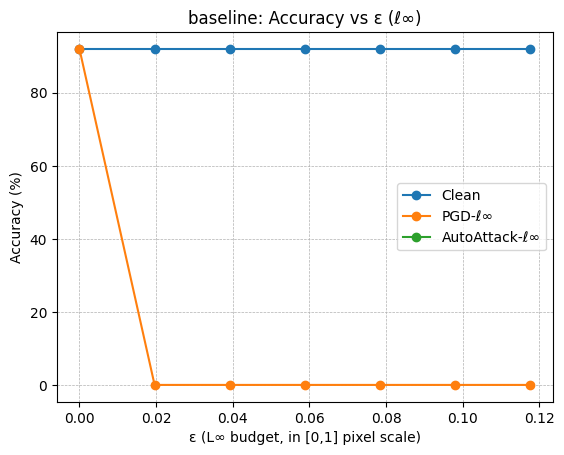

Saved: /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_linf/plots/baseline_acc_vs_eps_linf.png


<Figure size 640x480 with 0 Axes>

🔬 Running: Clean (No Attack)...


Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.5379, Accuracy: 82.93%
🔬 Running: Torch PGD (Linf)...


...

Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.5379, Accuracy: 82.93%
🔬 Running: Torch PGD (Linf)...


Eval [Torch PGD (Linf)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (Linf). Avg Loss: 12.5466, Accuracy: 0.65%

💾 Results saved to /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_linf/ta50/eps_0p11764706/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                      loss     acc
Clean (No Attack)   0.5379  82.93%
Torch PGD (Linf)   12.5466   0.65%
---------------------------------------



,eps,clean_acc,pgd_linf_acc,aa_linf_acc
0,0.000000,82.93,82.93,None
1,0.019608,82.93,63.47,None
2,0.039216,82.93,37.77,None
3,0.058824,82.93,17.36,None
4,0.078431,82.93,5.98,None
5,0.098039,82.93,1.87,None
6,0.117647,82.93,0.65,None


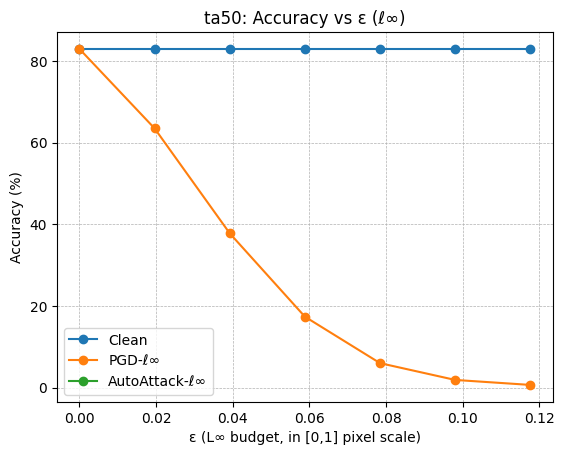

Saved: /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_linf/plots/ta50_acc_vs_eps_linf.png


<Figure size 640x480 with 0 Axes>

🔬 Running: Clean (No Attack)...


Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.5621, Accuracy: 82.51%
🔬 Running: Torch PGD (Linf)...


...

Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.5621, Accuracy: 82.51%
🔬 Running: Torch PGD (Linf)...


Eval [Torch PGD (Linf)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (Linf). Avg Loss: 12.3906, Accuracy: 0.71%

💾 Results saved to /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_linf/ta100/eps_0p11764706/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                      loss     acc
Clean (No Attack)   0.5621  82.51%
Torch PGD (Linf)   12.3906   0.71%
---------------------------------------



,eps,clean_acc,pgd_linf_acc,aa_linf_acc
0,0.000000,82.51,82.51,None
1,0.019608,82.51,63.24,None
2,0.039216,82.51,38.26,None
3,0.058824,82.51,17.44,None
4,0.078431,82.51,5.86,None
5,0.098039,82.51,1.81,None
6,0.117647,82.51,0.71,None


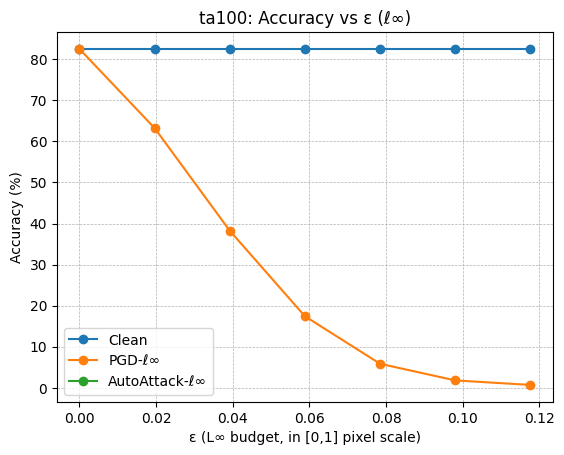

Saved: /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_linf/plots/ta100_acc_vs_eps_linf.png


<Figure size 640x480 with 0 Axes>

Saved: /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_linf/plots/overlay_pgd_linf_acc_vs_eps.png


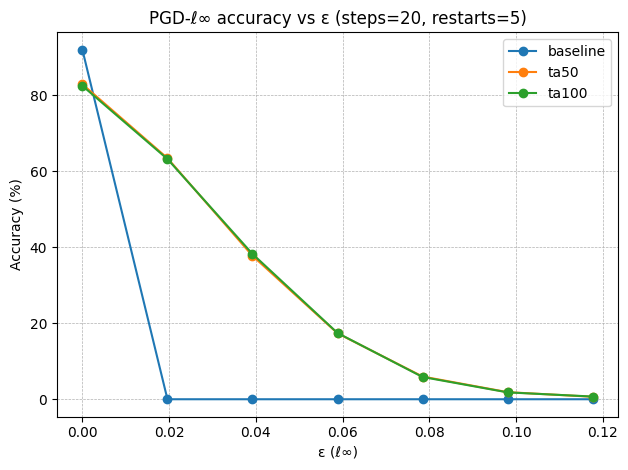

Saved: /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_linf/plots/overlay_clean_acc_vs_eps.png


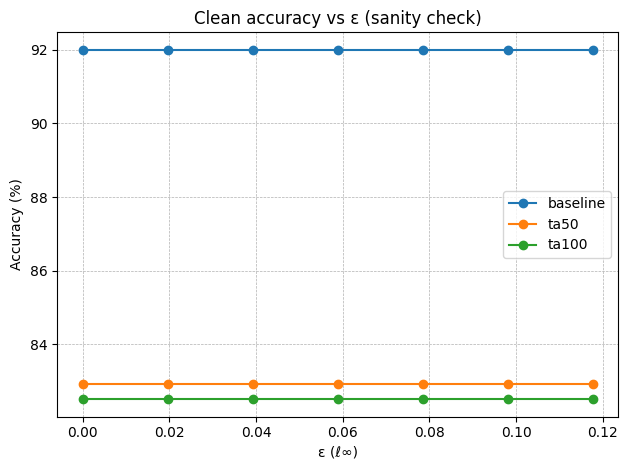

Saved CSV: /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_linf/acc_vs_eps_linf_pgd20_r5_all_models.csv


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Config
# ------------------------------------------------------------------
EVAL_EPS_ROOT = os.path.join(EVAL_BASE_DIR, "eps_sweeps_linf")
PLOT_DIR = os.path.join(EVAL_EPS_ROOT, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

eps_list = (0, 5/255, 10/255, 15/255, 20/255, 25/255, 30/255)

models = [
    ("baseline", base_model),
    ("ta50",     model),
    ("ta100",    model1),
]

# ------------------------------------------------------------------
# Helper: save current matplotlib figure
# ------------------------------------------------------------------
def save_plot(fname, dpi=200):
    path = os.path.join(PLOT_DIR, fname)
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")

# ------------------------------------------------------------------
# Run ε-sweeps
# ------------------------------------------------------------------
dfs = {}

for name, m in models:
    df = accuracy_vs_eps_linf(
        m,
        test_loader=test_loader,
        device=DEVICE,
        criterion=criterion,
        run_root=os.path.join(EVAL_EPS_ROOT, name),
        eps_list=eps_list,
        pgd_steps=20,
        pgd_restarts=5,
        include_pgd=True,
        include_autoattack=False,
    )
    dfs[name] = df
    display(df)

    # Individual plot
    plot_accuracy_vs_eps(df, title=f"{name}: Accuracy vs ε (ℓ∞)")
    save_plot(f"{name}_acc_vs_eps_linf.png")
    plt.show()

# ------------------------------------------------------------------
# Overlay plot: PGD-ℓ∞ (main figure for report)
# ------------------------------------------------------------------
plt.figure()
for name, _ in models:
    plt.plot(
        dfs[name]["eps"],
        dfs[name]["pgd_linf_acc"],
        marker="o",
        label=name,
    )

plt.xlabel("ε (ℓ∞)")
plt.ylabel("Accuracy (%)")
plt.title("PGD-ℓ∞ accuracy vs ε (steps=20, restarts=5)")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)

save_plot("overlay_pgd_linf_acc_vs_eps.png")
plt.show()

# ------------------------------------------------------------------
# Optional: overlay clean accuracy (sanity check)
# ------------------------------------------------------------------
plt.figure()
for name, _ in models:
    plt.plot(
        dfs[name]["eps"],
        dfs[name]["clean_acc"],
        marker="o",
        label=name,
    )

plt.xlabel("ε (ℓ∞)")
plt.ylabel("Accuracy (%)")
plt.title("Clean accuracy vs ε (sanity check)")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)

save_plot("overlay_clean_acc_vs_eps.png")
plt.show()

# ------------------------------------------------------------------
# Save combined CSV
# ------------------------------------------------------------------
df_long = pd.concat(
    [dfs[name].assign(model=name) for name, _ in models],
    ignore_index=True,
)

csv_path = os.path.join(EVAL_EPS_ROOT, "acc_vs_eps_linf_pgd20_r5_all_models.csv")
df_long.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path}")


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def accuracy_vs_eps_l2(
    model,
    *,
    test_loader,
    device,
    criterion,
    run_root,
    eps_list=(0.0, 0.25, 0.5, 1.0),
    pgd_l2_steps=20,
    alpha_l2=None,
    pgd_restarts=5,
    use_amp=True,
):
    os.makedirs(run_root, exist_ok=True)
    rows = []

    for eps_l2 in eps_list:
        run_dir = os.path.join(run_root, f"epsl2_{eps_l2:.6f}".replace(".", "p"))
        ev = Evaluator(model=model, test_loader=test_loader, device=device, run_dir=run_dir, use_amp=use_amp)

        # Always compute clean
        clean_results = ev.run(attacks_dict={})  # Evaluator should still run clean
        clean_acc = clean_results["Clean (No Attack)"]["acc"]

        # If eps=0, PGD-L2 == clean. Do not run the attack.
        if float(eps_l2) == 0.0:
            rows.append({
                "eps_l2": float(eps_l2),
                "clean_acc": clean_acc,
                "pgd_l2_acc": clean_acc,   # by definition
                "pgd_l2_loss": clean_results["Clean (No Attack)"]["loss"],
            })
            continue

        # step size heuristic
        a = (eps_l2 / 4) if (alpha_l2 is None) else float(alpha_l2)

        suite = make_attack_suite_for_model(
            model,
            criterion=criterion,
            device=device,
            frameworks=("torch",),
            attacks=("pgd_l2",),
            eps_l2=float(eps_l2),
            alpha_l2=float(a),
            pgd_l2_steps=int(pgd_l2_steps),
            pgd_restarts=int(pgd_restarts),
        )

        results = ev.run(attacks_dict=suite)

        pgd_key = "Torch PGD (L2)"
        rows.append({
            "eps_l2": float(eps_l2),
            "clean_acc": results["Clean (No Attack)"]["acc"],
            "pgd_l2_acc": results.get(pgd_key, {}).get("acc", None),
            "pgd_l2_loss": results.get(pgd_key, {}).get("loss", None),
        })

    return pd.DataFrame(rows).sort_values("eps_l2").reset_index(drop=True)


def plot_accuracy_vs_eps_l2(df, *, title="Accuracy vs ε (ℓ2)"):
    plt.figure()
    plt.plot(df["eps_l2"], df["clean_acc"], marker="o", label="Clean")
    plt.plot(df["eps_l2"], df["pgd_l2_acc"], marker="o", label="PGD-ℓ2")
    plt.xlabel("ε (ℓ2)")
    plt.ylabel("Accuracy (%)")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.5)


🔬 Running: Clean (No Attack)...


Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.2490, Accuracy: 92.00%
🔬 Running: Torch PGD (L2)...


Eval [Torch PGD (L2)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (L2). Avg Loss: nan, Accuracy: 10.00%

💾 Results saved to /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_l2/baseline/epsl2_0p000000/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                     loss     acc
Clean (No Attack)  0.2490  92.00%
Torch PGD (L2)        nan  10.00%
---------------------------------------

🔬 Running: Clean (No Attack)...


...

✅ Finished Clean (No Attack). Avg Loss: 0.2490, Accuracy: 92.00%
🔬 Running: Torch PGD (L2)...


Eval [Torch PGD (L2)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (L2). Avg Loss: 31.0778, Accuracy: 0.00%

💾 Results saved to /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_l2/baseline/epsl2_2p000000/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                      loss     acc
Clean (No Attack)   0.2490  92.00%
Torch PGD (L2)     31.0778   0.00%
---------------------------------------



,eps_l2,clean_acc,pgd_l2_acc
0,0.00,92.0,10.00
1,0.25,92.0,3.20
2,0.50,92.0,0.03
3,1.00,92.0,0.00
4,1.50,92.0,0.00
5,2.00,92.0,0.00


Saved: /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_l2/plots/baseline_acc_vs_eps_l2.png


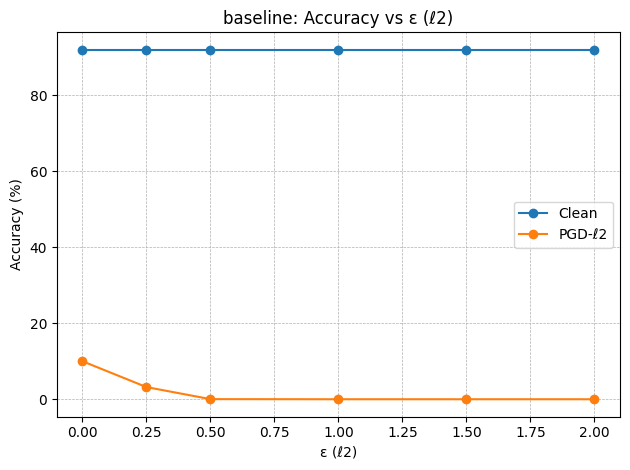

🔬 Running: Clean (No Attack)...


Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.5379, Accuracy: 82.93%
🔬 Running: Torch PGD (L2)...


Eval [Torch PGD (L2)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (L2). Avg Loss: nan, Accuracy: 10.00%

💾 Results saved to /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_l2/ta50/epsl2_0p000000/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                     loss     acc
Clean (No Attack)  0.5379  82.93%
Torch PGD (L2)        nan  10.00%
---------------------------------------

🔬 Running: Clean (No Attack)...


...

✅ Finished Clean (No Attack). Avg Loss: 0.5379, Accuracy: 82.93%
🔬 Running: Torch PGD (L2)...


Eval [Torch PGD (L2)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (L2). Avg Loss: 6.7039, Accuracy: 2.85%

💾 Results saved to /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_l2/ta50/epsl2_2p000000/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                     loss     acc
Clean (No Attack)  0.5379  82.93%
Torch PGD (L2)     6.7039   2.85%
---------------------------------------



,eps_l2,clean_acc,pgd_l2_acc
0,0.00,82.93,10.00
1,0.25,82.93,73.16
2,0.50,82.93,60.32
3,1.00,82.93,30.19
4,1.50,82.93,10.68
5,2.00,82.93,2.85


Saved: /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_l2/plots/ta50_acc_vs_eps_l2.png


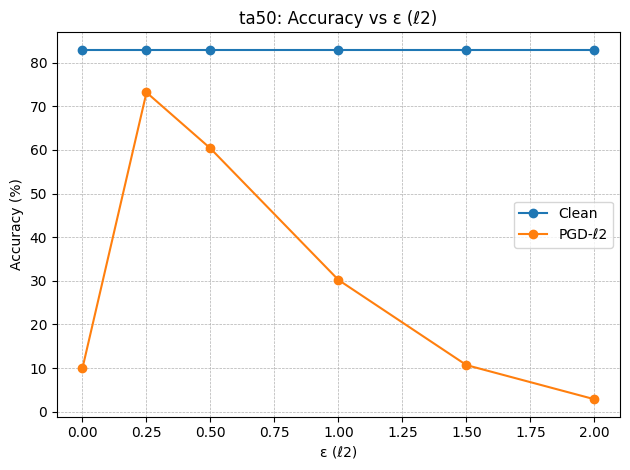

🔬 Running: Clean (No Attack)...


Eval [Clean (No Attack)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Clean (No Attack). Avg Loss: 0.5621, Accuracy: 82.51%
🔬 Running: Torch PGD (L2)...


Eval [Torch PGD (L2)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (L2). Avg Loss: nan, Accuracy: 10.00%

💾 Results saved to /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_l2/ta100/epsl2_0p000000/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                     loss     acc
Clean (No Attack)  0.5621  82.51%
Torch PGD (L2)        nan  10.00%
---------------------------------------

🔬 Running: Clean (No Attack)...


...

✅ Finished Clean (No Attack). Avg Loss: 0.5621, Accuracy: 82.51%
🔬 Running: Torch PGD (L2)...


Eval [Torch PGD (L2)]:   0%|          | 0/79 [00:00<?, ?it/s]

✅ Finished Torch PGD (L2). Avg Loss: 6.7274, Accuracy: 2.94%

💾 Results saved to /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_l2/ta100/epsl2_2p000000/evaluation_results.json

--- 🛡️ Robustness Evaluation Summary ---
                     loss     acc
Clean (No Attack)  0.5621  82.51%
Torch PGD (L2)     6.7274   2.94%
---------------------------------------



,eps_l2,clean_acc,pgd_l2_acc
0,0.00,82.51,10.00
1,0.25,82.51,72.96
2,0.50,82.51,59.48
3,1.00,82.51,30.33
4,1.50,82.51,10.69
5,2.00,82.51,2.94


Saved: /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_l2/plots/ta100_acc_vs_eps_l2.png


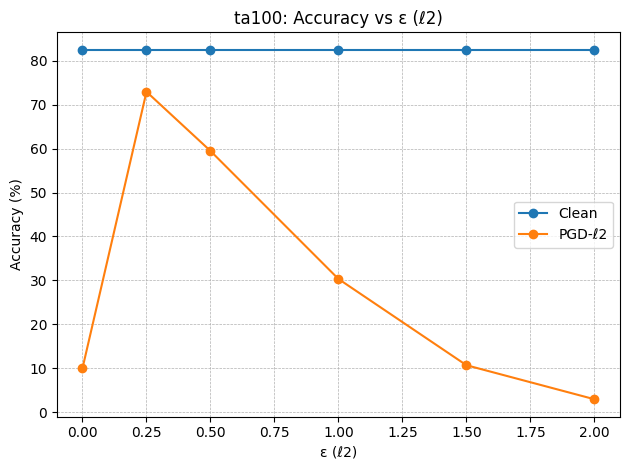

Saved: /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_l2/plots/overlay_pgd_l2_acc_vs_eps.png


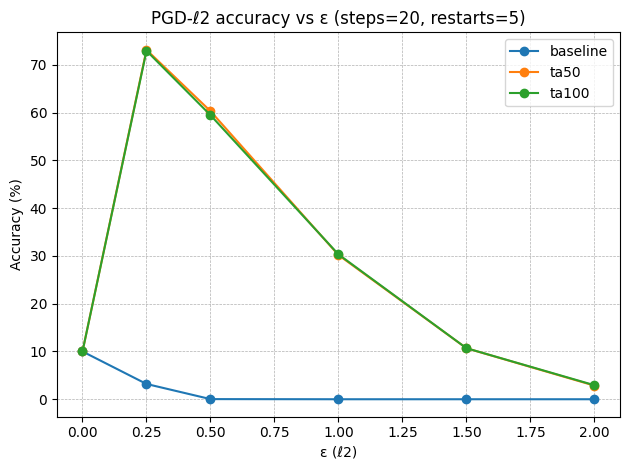

Saved CSV: /content/drive/MyDrive/Kiet_experiments/eval/eps_sweeps_l2/acc_vs_eps_l2_pgd20_r5_all_models.csv


In [ ]:
# ------------------------------------------------------------------
# Config (L2)
# ------------------------------------------------------------------
EVAL_EPS_L2_ROOT = os.path.join(EVAL_BASE_DIR, "eps_sweeps_l2")
PLOT_L2_DIR = os.path.join(EVAL_EPS_L2_ROOT, "plots")
os.makedirs(PLOT_L2_DIR, exist_ok=True)

# Choose a reasonable L2 grid for CIFAR-10-scale images.
# Common starting points: 0.25, 0.5, 1.0, 1.5, 2.0 (depends on your implementation).
eps_l2_list = (0.0, 0.25, 0.5, 1.0, 1.5, 2.0)

models = [
    ("baseline", base_model),
    ("ta50",     model),
    ("ta100",    model1),
]

def save_plot_l2(fname, dpi=200):
    path = os.path.join(PLOT_L2_DIR, fname)
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")

# ------------------------------------------------------------------
# Run ε-sweeps (L2)
# ------------------------------------------------------------------
dfs_l2 = {}

for name, m in models:
    df = accuracy_vs_eps_l2(
        m,
        test_loader=test_loader,
        device=DEVICE,
        criterion=criterion,
        run_root=os.path.join(EVAL_EPS_L2_ROOT, name),
        eps_list=eps_l2_list,
        pgd_l2_steps=20,
        pgd_restarts=5,
        alpha_l2=None,      # uses eps/4
    )
    dfs_l2[name] = df
    display(df)

    plot_accuracy_vs_eps_l2(df, title=f"{name}: Accuracy vs ε (ℓ2)")
    save_plot_l2(f"{name}_acc_vs_eps_l2.png")
    plt.show()

# ------------------------------------------------------------------
# Overlay plot: PGD-ℓ2
# ------------------------------------------------------------------
plt.figure()
for name, _ in models:
    plt.plot(dfs_l2[name]["eps_l2"], dfs_l2[name]["pgd_l2_acc"], marker="o", label=name)

plt.xlabel("ε (ℓ2)")
plt.ylabel("Accuracy (%)")
plt.title("PGD-ℓ2 accuracy vs ε (steps=20, restarts=5)")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)

save_plot_l2("overlay_pgd_l2_acc_vs_eps.png")
plt.show()

# ------------------------------------------------------------------
# Save combined CSV
# ------------------------------------------------------------------
df_l2_long = pd.concat([dfs_l2[name].assign(model=name) for name, _ in models], ignore_index=True)
csv_path = os.path.join(EVAL_EPS_L2_ROOT, "acc_vs_eps_l2_pgd20_r5_all_models.csv")
df_l2_long.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path}")


In [ ]:
import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def denorm_to_uint8(x_norm_chw):
    """
    x_norm_chw: torch.Tensor (3,H,W) normalized
    returns: uint8 numpy array (H,W,3) in [0,255]
    """
    x = x_norm_chw.unsqueeze(0)  # (1,3,H,W)
    x = Evaluator._unnormalize(x, CIFAR10_MEAN, CIFAR10_STD).clamp(0, 1)
    x = (x[0].permute(1, 2, 0).cpu().numpy() * 255.0).round().astype(np.uint8)
    return x

@torch.no_grad()
def select_first_n_clean_correct(model, loader, device, n=8, seed=42):
    """
    Deterministic protocol: iterate loader order (no shuffle) and keep first n samples
    correctly classified by model on clean inputs.
    Returns: (x_sel, y_sel) tensors on device with shapes (n,3,H,W), (n,)
    """
    set_all_seeds(seed)
    model.eval()

    xs, ys = [], []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        ok = (pred == y)

        if ok.any():
            idxs = ok.nonzero(as_tuple=False).squeeze(1).tolist()
            for i in idxs:
                xs.append(x[i].detach())
                ys.append(y[i].detach())
                if len(xs) >= n:
                    x_sel = torch.stack(xs, dim=0)
                    y_sel = torch.stack(ys, dim=0)
                    return x_sel, y_sel

    raise RuntimeError(f"Could not find {n} clean-correct samples in loader.")

def save_grid_figure(
    images_by_col,  # list of lists: columns, each is list of N uint8 images (H,W,3)
    col_titles,
    out_path,
    suptitle=None,
    dpi=200,
):
    """
    images_by_col: [col0_imgs, col1_imgs, ...], each colk_imgs length N
    """
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    ncols = len(images_by_col)
    nrows = len(images_by_col[0])

    plt.figure(figsize=(3.2*ncols, 2.2*nrows))
    for r in range(nrows):
        for c in range(ncols):
            ax = plt.subplot(nrows, ncols, r*ncols + c + 1)
            ax.imshow(images_by_col[c][r])
            ax.axis("off")
            if r == 0:
                ax.set_title(col_titles[c])

    if suptitle is not None:
        plt.suptitle(suptitle)

    plt.tight_layout()
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.close()
    print(f"Saved: {out_path}")


In [ ]:
# -----------------------------
# Figure 5.1 / ch5_grid_norms
# -----------------------------
set_all_seeds(42)

N = 8
x_sel, y_sel = select_first_n_clean_correct(model, test_loader, DEVICE, n=N, seed=42)

# Attack settings: adapt to match your evaluation section
eps_linf = 8/255
alpha_linf = 2/255
steps_linf = 50
restarts = 1

eps_l2 = 0.5
alpha_l2 = 0.1
steps_l2 = 50

suite_norms = make_attack_suite_for_model(
    model,
    criterion=criterion,
    device=DEVICE,
    frameworks=("torch",),
    attacks=("pgd", "pgd_l2"),
    eps=eps_linf,
    alpha=alpha_linf,
    pgd_steps=steps_linf,
    pgd_restarts=restarts,
    eps_l2=eps_l2,
    alpha_l2=alpha_l2,
    pgd_l2_steps=steps_l2,
)

x_clean = x_sel
x_pgd_linf = generate_adv(suite_norms["Torch PGD (Linf)"], x_sel, y_sel).detach()
x_pgd_l2   = generate_adv(suite_norms["Torch PGD (L2)"],   x_sel, y_sel).detach()

# Convert to uint8 for plotting
col_clean = [denorm_to_uint8(x_clean[i]) for i in range(N)]
col_linf  = [denorm_to_uint8(x_pgd_linf[i]) for i in range(N)]
col_l2    = [denorm_to_uint8(x_pgd_l2[i]) for i in range(N)]

save_grid_figure(
    images_by_col=[col_clean, col_linf, col_l2],
    col_titles=["Clean", r"PGD-$\ell_\infty$", r"PGD-$\ell_2$"],
    out_path="figs/ch5_grid_norms.png",
    suptitle="Qualitative norm comparison (TA-50, N=8 clean-correct samples)",
    dpi=200,
)


Saved: figs/ch5_grid_norms.png


In [ ]:
# ---------------------------------------
# Figure 5.2 / ch5_grid_attacks
# ---------------------------------------
set_all_seeds(42)

N = 8
x_sel, y_sel = select_first_n_clean_correct(model, test_loader, DEVICE, n=N, seed=42)

# Settings (adjust to match your chapter text)
eps_linf = 8/255
alpha_linf = 2/255
steps_linf = 50
restarts = 1

# CW params (these can be expensive; keep steps moderate for visualization)
cw_steps = 100
cw_lr = 0.01

suite_attacks = make_attack_suite_for_model(
    model,
    criterion=criterion,
    device=DEVICE,
    frameworks=("torch", "aa_orig"),
    attacks=("pgd", "autoattack", "cw"),
    eps=eps_linf,
    alpha=alpha_linf,
    pgd_steps=steps_linf,
    pgd_restarts=restarts,
    aa_version="standard",
    cw_steps=cw_steps,
    cw_lr=cw_lr,
)

x_clean = x_sel
x_pgd_linf = generate_adv(suite_attacks["Torch PGD (Linf)"], x_sel, y_sel).detach()

# AutoAttack key in your notebook is typically "AutoAttack (orig)"
x_aa = generate_adv(suite_attacks["AutoAttack (orig)"], x_sel, y_sel).detach()

x_cw_l2 = generate_adv(suite_attacks["Torch CW (L2)"], x_sel, y_sel).detach()

# Convert to uint8 for plotting
col_clean = [denorm_to_uint8(x_clean[i]) for i in range(N)]
col_pgd   = [denorm_to_uint8(x_pgd_linf[i]) for i in range(N)]
col_aa    = [denorm_to_uint8(x_aa[i]) for i in range(N)]
col_cw    = [denorm_to_uint8(x_cw_l2[i]) for i in range(N)]

save_grid_figure(
    images_by_col=[col_clean, col_pgd, col_aa, col_cw],
    col_titles=["Clean", r"PGD-$\ell_\infty$", "AutoAttack", r"CW-$\ell_2$"],
    out_path="figs/ch5_grid_attacks.png",
    suptitle="Qualitative attack-family comparison (TA-50, N=8 clean-correct samples)",
    dpi=200,
)


setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 100.00%
apgd-ce - 1/1 - 5 out of 8 successfully perturbed
robust accuracy after APGD-CE: 37.50% (total time 0.9 s)
apgd-t - 1/1 - 1 out of 3 successfully perturbed
robust accuracy after APGD-T: 25.00% (total time 8.7 s)
fab-t - 1/1 - 0 out of 2 successfully perturbed
robust accuracy after FAB-T: 25.00% (total time 24.6 s)
square - 1/1 - 0 out of 2 successfully perturbed
robust accuracy after SQUARE: 25.00% (total time 46.1 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 25.00%
Saved: figs/ch5_grid_attacks.png


In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

@torch.no_grad()
def predict_correct_mask(model, x_norm, y, device):
    """Return bool mask (N,) whether model(x_norm) == y."""
    model.eval()
    logits = model(x_norm.to(device))
    pred = logits.argmax(dim=1)
    return (pred == y.to(device)).detach().cpu().numpy(), pred.detach().cpu().numpy()

def denorm_to_float01(x_norm):
    """
    x_norm: (N,3,H,W) normalized
    -> float tensor (N,3,H,W) in [0,1]
    """
    x = Evaluator._unnormalize(x_norm, CIFAR10_MEAN, CIFAR10_STD)
    return x.clamp(0, 1)

def to_hwc_uint8(x_float01_chw):
    """(3,H,W) float in [0,1] -> uint8 (H,W,3)"""
    return (x_float01_chw.permute(1,2,0).cpu().numpy() * 255.0).round().astype(np.uint8)

def perturbation_to_hwc_uint8(delta_float, scale=None):
    """
    delta_float: (3,H,W) in [-1,1] roughly (pixel space difference)
    Convert to visible RGB: 0.5 + delta/scale mapped to [0,1].
    If scale is None, uses max-abs per-image (robust for display).
    """
    d = delta_float.detach().cpu()
    if scale is None:
        max_abs = d.abs().max().item()
        scale = max(max_abs, 1e-8)
    vis = (0.5 + d / (2.0 * scale)).clamp(0, 1)  # 0.5 means no change
    return to_hwc_uint8(vis)

def save_attack_grid_with_boxes_and_deltas(
    *,
    model_for_boxes,      # the model whose correctness you want to display (TA-50 in your write-up)
    x_clean_norm,         # (N,3,H,W) normalized
    y,                    # (N,)
    columns,              # list of dicts: [{"title": "...", "x_adv_norm": tensor or None, "show_delta": bool}, ...]
    out_path,
    suptitle=None,
    dpi=200,
    device=None,
    delta_scale_map=None, # optional dict mapping title -> scale value for perturbation visualization
):
    """
    Produces a grid with 2*Nrows if any column has show_delta=True:
      row 0..N-1: images
      row N..2N-1: perturbations for columns where show_delta=True, otherwise blank
    Bounding box color indicates correctness of model_for_boxes on that cell's image.
    """
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    device = device or (x_clean_norm.device if hasattr(x_clean_norm, "device") else "cpu")

    N = x_clean_norm.shape[0]
    ncols = len(columns)
    has_delta_row = any(col.get("show_delta", False) for col in columns)
    nrows = 2 * N if has_delta_row else N

    # denorm clean once
    x_clean_01 = denorm_to_float01(x_clean_norm)

    # precompute correctness on clean
    clean_ok, clean_pred = predict_correct_mask(model_for_boxes, x_clean_norm, y, device)

    # For each column, compute images + correctness + perturbations
    col_imgs = []
    col_ok_masks = []
    col_preds = []
    col_deltas = []

    for col in columns:
        x_adv_norm = col.get("x_adv_norm", None)
        if x_adv_norm is None:
            x_col_norm = x_clean_norm
            x_col_01 = x_clean_01
            ok_mask = clean_ok
            preds = clean_pred
            delta_vis_list = [None] * N
        else:
            x_col_norm = x_adv_norm
            x_col_01 = denorm_to_float01(x_col_norm)
            ok_mask, preds = predict_correct_mask(model_for_boxes, x_col_norm, y, device)

            if col.get("show_delta", False):
                # delta in pixel space
                delta = (x_col_01 - x_clean_01)  # (N,3,H,W)
                scale = None
                if delta_scale_map is not None:
                    scale = delta_scale_map.get(col["title"], None)
                delta_vis_list = [perturbation_to_hwc_uint8(delta[i], scale=scale) for i in range(N)]
            else:
                delta_vis_list = [None] * N

        imgs_uint8 = [to_hwc_uint8(x_col_01[i]) for i in range(N)]
        col_imgs.append(imgs_uint8)
        col_ok_masks.append(ok_mask)
        col_preds.append(preds)
        col_deltas.append(delta_vis_list)

    # Draw
    plt.figure(figsize=(3.3*ncols, 2.2*nrows))
    for r in range(N):
        for c in range(ncols):
            ax = plt.subplot(nrows, ncols, r*ncols + c + 1)
            ax.imshow(col_imgs[c][r])
            ax.axis("off")
            if r == 0:
                ax.set_title(columns[c]["title"])

            # bounding box
            ok = bool(col_ok_masks[c][r])
            edge = "green" if ok else "red"
            rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                     fill=False, linewidth=3, edgecolor=edge)
            ax.add_patch(rect)

            # optional: tiny label with predicted class id
            # ax.text(0.02, 0.06, f"pred={col_preds[c][r]}", transform=ax.transAxes,
            #         fontsize=8, color=edge, bbox=dict(facecolor="black", alpha=0.3, pad=1))

        if has_delta_row:
            rr = N + r
            for c in range(ncols):
                ax = plt.subplot(nrows, ncols, rr*ncols + c + 1)
                ax.axis("off")

                if columns[c].get("show_delta", False) and col_deltas[c][r] is not None:
                    ax.imshow(col_deltas[c][r])
                    # Add a neutral gray box to indicate "delta row"
                    rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                             fill=False, linewidth=1.5, edgecolor="white")
                    ax.add_patch(rect)
                else:
                    # leave blank cell for columns that do not show delta
                    pass

                if r == 0:
                    # label delta row once per column (on first delta row)
                    if columns[c].get("show_delta", False):
                        ax.set_title("Δ (scaled)", fontsize=10)

    if suptitle:
        plt.suptitle(suptitle)

    plt.tight_layout()
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.close()
    print(f"Saved: {out_path}")


In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def delta_mag_uint8(clean_01, adv_01, scale=None):
    """
    Magnitude visualization: ||adv-clean|| per-pixel, mapped to [0,255].
    clean_01, adv_01: (3,H,W) in [0,1]
    """
    d = (adv_01 - clean_01).detach().cpu()
    mag = torch.sqrt((d**2).sum(dim=0))  # (H,W)
    if scale is None:
        scale = mag.max().item()
        scale = max(scale, 1e-8)
    vis = (mag / scale).clamp(0, 1)
    img = (vis.numpy() * 255.0).round().astype(np.uint8)
    return np.stack([img, img, img], axis=-1)  # (H,W,3)

def delta_signed_rgb_uint8(clean_01, adv_01, scale=None):
    """
    Signed RGB visualization: 0.5 + (adv-clean)/(2*scale), mapped to [0,255].
    """
    d = (adv_01 - clean_01).detach().cpu()
    if scale is None:
        scale = d.abs().max().item()
        scale = max(scale, 1e-8)
    vis = (0.5 + d / (2.0 * scale)).clamp(0, 1)
    img = (vis.permute(1,2,0).numpy() * 255.0).round().astype(np.uint8)
    return img

@torch.no_grad()
def pred_ok(model, x_norm, y, device):
    model.eval()
    pred = model(x_norm.to(device)).argmax(dim=1)
    ok = (pred == y.to(device))
    return ok.detach().cpu().numpy(), pred.detach().cpu().numpy()

def make_clean_delta_adv_grid(
    *,
    model_for_boxes,
    x_clean_norm,     # (N,3,H,W) normalized
    y,                # (N,)
    groups,           # list of dicts: {"name": "PGD-linf", "x_adv_norm": tensor (N,3,H,W)}
    out_path,
    device,
    delta_mode="mag", # "mag" or "signed"
    delta_scale_map=None, # optional dict group_name -> scale
    dpi=200,
):
    """
    Columns per group = 3: Clean | Δ | Adv
    Total columns = 3 * len(groups)
    Bounding boxes drawn on Adv columns only.
    """
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    N = x_clean_norm.shape[0]
    G = len(groups)
    ncols = 3 * G
    nrows = N

    # denorm clean once
    x_clean_01 = denorm_to_float01(x_clean_norm)  # (N,3,H,W)

    # precompute clean images once (uint8)
    clean_imgs = [to_hwc_uint8(x_clean_01[i]) for i in range(N)]

    # precompute adv images and deltas
    adv_imgs_by_group = []
    delta_imgs_by_group = []
    ok_by_group = []

    for g in groups:
        x_adv_norm = g["x_adv_norm"]
        x_adv_01 = denorm_to_float01(x_adv_norm)

        adv_imgs = [to_hwc_uint8(x_adv_01[i]) for i in range(N)]

        # correctness (on adv)
        ok_mask, _ = pred_ok(model_for_boxes, x_adv_norm, y, device)

        # delta visualization
        scale = None
        if delta_scale_map is not None:
            scale = delta_scale_map.get(g["name"], None)

        if delta_mode == "signed":
            deltas = [delta_signed_rgb_uint8(x_clean_01[i], x_adv_01[i], scale=scale) for i in range(N)]
        else:
            deltas = [delta_mag_uint8(x_clean_01[i], x_adv_01[i], scale=scale) for i in range(N)]

        adv_imgs_by_group.append(adv_imgs)
        delta_imgs_by_group.append(deltas)
        ok_by_group.append(ok_mask)

    # draw
    plt.figure(figsize=(3.0*ncols, 2.2*nrows))
    for r in range(N):
        for gi, g in enumerate(groups):
            c0 = 3*gi

            # Clean
            ax = plt.subplot(nrows, ncols, r*ncols + c0 + 1)
            ax.imshow(clean_imgs[r]); ax.axis("off")
            if r == 0:
                ax.set_title("Clean", fontsize=11)

            # Δ
            ax = plt.subplot(nrows, ncols, r*ncols + c0 + 2)
            ax.imshow(delta_imgs_by_group[gi][r]); ax.axis("off")
            if r == 0:
                ax.set_title("Δ", fontsize=11)

            # Adv (with box)
            ax = plt.subplot(nrows, ncols, r*ncols + c0 + 3)
            ax.imshow(adv_imgs_by_group[gi][r]); ax.axis("off")
            if r == 0:
                ax.set_title("Adv", fontsize=11)

            ok = bool(ok_by_group[gi][r])
            edge = "green" if ok else "red"
            rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                     fill=False, linewidth=3, edgecolor=edge)
            ax.add_patch(rect)

    # group headers above each triplet
    fig = plt.gcf()
    for gi, g in enumerate(groups):
        # x position in figure coords
        x_center = (3*gi + 1.5) / ncols
        fig.text(x_center, 0.995, g["name"], ha="center", va="top", fontsize=13)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.close()
    print(f"Saved: {out_path}")


In [ ]:
# Select N=8 clean-correct for TA-50
N = 8
x_sel, y_sel = select_first_n_clean_correct(model, test_loader, DEVICE, n=N, seed=42)

# Build suite and generate adversarial examples
eps_linf, alpha_linf, steps_linf = 8/255, 2/255, 50
cw_steps, cw_lr = 100, 0.01

suite_attacks = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch", "aa_orig"),
    attacks=("pgd", "autoattack", "cw"),
    eps=eps_linf, alpha=alpha_linf, pgd_steps=steps_linf, pgd_restarts=1,
    aa_version="standard",
    cw_steps=cw_steps, cw_lr=cw_lr,
)

x_pgd_linf = generate_adv(suite_attacks["Torch PGD (Linf)"], x_sel, y_sel).detach()
x_aa       = generate_adv(suite_attacks["AutoAttack (orig)"], x_sel, y_sel).detach()
x_cw_l2    = generate_adv(suite_attacks["Torch CW (L2)"],      x_sel, y_sel).detach()

make_clean_delta_adv_grid(
    model_for_boxes=model,  # TA-50 correctness on ADV column
    x_clean_norm=x_sel,
    y=y_sel,
    groups=[
        {"name": r"PGD-$\ell_\infty$", "x_adv_norm": x_pgd_linf},
        {"name": "AutoAttack",         "x_adv_norm": x_aa},
        {"name": r"CW-$\ell_2$",       "x_adv_norm": x_cw_l2},
    ],
    out_path="figs/ch5_grid_attacks_cda.png",
    device=DEVICE,
    delta_mode="mag",  # "mag" is usually more readable in print
    # Optional fixed scaling for consistent Δ contrast across groups:
    # delta_scale_map={r"PGD-$\ell_\infty$": 0.15, "AutoAttack": 0.15, r"CW-$\ell_2$": 0.15},
    dpi=200,
)


setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 100.00%
apgd-ce - 1/1 - 5 out of 8 successfully perturbed
robust accuracy after APGD-CE: 37.50% (total time 0.8 s)
apgd-t - 1/1 - 1 out of 3 successfully perturbed
robust accuracy after APGD-T: 25.00% (total time 8.1 s)
fab-t - 1/1 - 0 out of 2 successfully perturbed
robust accuracy after FAB-T: 25.00% (total time 24.2 s)
square - 1/1 - 0 out of 2 successfully perturbed
robust accuracy after SQUARE: 25.00% (total time 46.0 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 25.00%
Saved: figs/ch5_grid_attacks_cda.png


In [ ]:
eps_linf, alpha_linf, steps_linf = 8/255, 2/255, 50
eps_l2, alpha_l2, steps_l2 = 0.5, 0.1, 50

suite_norms = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch",),
    attacks=("pgd", "pgd_l2"),
    eps=eps_linf, alpha=alpha_linf, pgd_steps=steps_linf, pgd_restarts=1,
    eps_l2=eps_l2, alpha_l2=alpha_l2, pgd_l2_steps=steps_l2,
)

x_pgd_linf = generate_adv(suite_norms["Torch PGD (Linf)"], x_sel, y_sel).detach()
x_pgd_l2   = generate_adv(suite_norms["Torch PGD (L2)"],   x_sel, y_sel).detach()

make_clean_delta_adv_grid(
    model_for_boxes=model,
    x_clean_norm=x_sel,
    y=y_sel,
    groups=[
        {"name": r"PGD-$\ell_\infty$", "x_adv_norm": x_pgd_linf},
        {"name": r"PGD-$\ell_2$",      "x_adv_norm": x_pgd_l2},
    ],
    out_path="figs/ch5_grid_norms_cda.png",
    device=DEVICE,
    delta_mode="mag",
    dpi=200,
)


Saved: figs/ch5_grid_norms_cda.png


In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def delta_mag_uint8(clean_01, adv_01, scale=None):
    d = (adv_01 - clean_01).detach().cpu()
    mag = torch.sqrt((d**2).sum(dim=0))  # (H,W)
    if scale is None:
        scale = mag.max().item()
        scale = max(scale, 1e-8)
    vis = (mag / scale).clamp(0, 1)
    img = (vis.numpy() * 255.0).round().astype(np.uint8)
    return np.stack([img, img, img], axis=-1)

def delta_signed_rgb_uint8(clean_01, adv_01, scale=None):
    d = (adv_01 - clean_01).detach().cpu()
    if scale is None:
        scale = d.abs().max().item()
        scale = max(scale, 1e-8)
    vis = (0.5 + d / (2.0 * scale)).clamp(0, 1)
    img = (vis.permute(1,2,0).numpy() * 255.0).round().astype(np.uint8)
    return img

@torch.no_grad()
def pred_ok(model, x_norm, y, device):
    model.eval()
    pred = model(x_norm.to(device)).argmax(dim=1)
    ok = (pred == y.to(device))
    return ok.detach().cpu().numpy(), pred.detach().cpu().numpy()

def make_clean_once_delta_adv_grid(
    *,
    model_for_boxes,
    x_clean_norm,     # (N,3,H,W) normalized
    y,                # (N,)
    attacks,          # list of dicts: {"name": "...", "x_adv_norm": tensor (N,3,H,W)}
    out_path,
    device,
    delta_mode="mag",     # "mag" or "signed"
    delta_scale_map=None, # optional dict attack_name -> scale
    dpi=200,
):
    """
    Layout:
      Col 0: Clean (shown once)
      Then for each attack k:
        Col 1+2k:   Δ
        Col 2+2k:   Adv (with green/red correctness box)
    """
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    N = x_clean_norm.shape[0]
    K = len(attacks)
    ncols = 1 + 2*K
    nrows = N

    # denorm clean once
    x_clean_01 = denorm_to_float01(x_clean_norm)  # (N,3,H,W)
    clean_imgs = [to_hwc_uint8(x_clean_01[i]) for i in range(N)]

    adv_imgs_by_attack = []
    delta_imgs_by_attack = []
    ok_by_attack = []

    for atk in attacks:
        x_adv_norm = atk["x_adv_norm"]
        x_adv_01 = denorm_to_float01(x_adv_norm)
        adv_imgs = [to_hwc_uint8(x_adv_01[i]) for i in range(N)]

        ok_mask, _ = pred_ok(model_for_boxes, x_adv_norm, y, device)

        scale = None
        if delta_scale_map is not None:
            scale = delta_scale_map.get(atk["name"], None)

        if delta_mode == "signed":
            deltas = [delta_signed_rgb_uint8(x_clean_01[i], x_adv_01[i], scale=scale) for i in range(N)]
        else:
            deltas = [delta_mag_uint8(x_clean_01[i], x_adv_01[i], scale=scale) for i in range(N)]

        adv_imgs_by_attack.append(adv_imgs)
        delta_imgs_by_attack.append(deltas)
        ok_by_attack.append(ok_mask)

    # draw
    plt.figure(figsize=(3.0*ncols, 2.2*nrows))

    for r in range(N):
        # Clean col
        ax = plt.subplot(nrows, ncols, r*ncols + 1)
        ax.imshow(clean_imgs[r]); ax.axis("off")
        if r == 0:
            ax.set_title("Clean", fontsize=11)

        # Attack columns
        for k, atk in enumerate(attacks):
            c_delta = 1 + 2*k
            c_adv   = 2 + 2*k

            ax = plt.subplot(nrows, ncols, r*ncols + c_delta + 1)
            ax.imshow(delta_imgs_by_attack[k][r]); ax.axis("off")
            if r == 0:
                ax.set_title("Δ", fontsize=11)

            ax = plt.subplot(nrows, ncols, r*ncols + c_adv + 1)
            ax.imshow(adv_imgs_by_attack[k][r]); ax.axis("off")
            if r == 0:
                ax.set_title("Adv", fontsize=11)

            ok = bool(ok_by_attack[k][r])
            edge = "green" if ok else "red"
            rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                     fill=False, linewidth=3, edgecolor=edge)
            ax.add_patch(rect)

    # group headers centered above each (Δ,Adv) pair
    fig = plt.gcf()
    for k, atk in enumerate(attacks):
        # center of the pair columns in figure fraction
        col_center = (1 + 2*k + 1.5) / ncols
        fig.text(col_center, 0.995, atk["name"], ha="center", va="top", fontsize=13)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.close()
    print(f"Saved: {out_path}")


In [ ]:
# Select fixed set (already deterministic by your protocol)
N = 8
x_sel, y_sel = select_first_n_clean_correct(model, test_loader, DEVICE, n=N, seed=42)

# Generate adversarial examples (as you already do)
eps_linf, alpha_linf, steps_linf = 8/255, 2/255, 50
cw_steps, cw_lr = 100, 0.01

suite_attacks = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch", "aa_orig"),
    attacks=("pgd", "autoattack", "cw"),
    eps=eps_linf, alpha=alpha_linf, pgd_steps=steps_linf, pgd_restarts=1,
    aa_version="standard",
    cw_steps=cw_steps, cw_lr=cw_lr,
)

x_pgd_linf = generate_adv(suite_attacks["Torch PGD (Linf)"], x_sel, y_sel).detach()
x_aa       = generate_adv(suite_attacks["AutoAttack (orig)"], x_sel, y_sel).detach()
x_cw_l2    = generate_adv(suite_attacks["Torch CW (L2)"],      x_sel, y_sel).detach()

make_clean_once_delta_adv_grid(
    model_for_boxes=model,     # TA-50 correctness boxes
    x_clean_norm=x_sel,
    y=y_sel,
    attacks=[
        {"name": r"PGD-$\ell_\infty$", "x_adv_norm": x_pgd_linf},
        {"name": "AutoAttack",         "x_adv_norm": x_aa},
        {"name": r"CW-$\ell_2$",       "x_adv_norm": x_cw_l2},
    ],
    out_path="figs/ch5_grid_attacks_clean_once.png",
    device=DEVICE,
    delta_mode="mag",          # recommended for print; use "signed" if you prefer
    dpi=200,
)


setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 100.00%
apgd-ce - 1/1 - 5 out of 8 successfully perturbed
robust accuracy after APGD-CE: 37.50% (total time 0.8 s)
apgd-t - 1/1 - 1 out of 3 successfully perturbed
robust accuracy after APGD-T: 25.00% (total time 8.5 s)
fab-t - 1/1 - 0 out of 2 successfully perturbed
robust accuracy after FAB-T: 25.00% (total time 24.9 s)
square - 1/1 - 0 out of 2 successfully perturbed
robust accuracy after SQUARE: 25.00% (total time 46.8 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 25.00%
Saved: figs/ch5_grid_attacks_clean_once.png


In [ ]:
eps_linf, alpha_linf, steps_linf = 8/255, 2/255, 50
eps_l2, alpha_l2, steps_l2 = 0.5, 0.1, 50

suite_norms = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch",),
    attacks=("pgd", "pgd_l2"),
    eps=eps_linf, alpha=alpha_linf, pgd_steps=steps_linf, pgd_restarts=1,
    eps_l2=eps_l2, alpha_l2=alpha_l2, pgd_l2_steps=steps_l2,
)

x_pgd_linf = generate_adv(suite_norms["Torch PGD (Linf)"], x_sel, y_sel).detach()
x_pgd_l2   = generate_adv(suite_norms["Torch PGD (L2)"],   x_sel, y_sel).detach()

make_clean_once_delta_adv_grid(
    model_for_boxes=model,
    x_clean_norm=x_sel,
    y=y_sel,
    attacks=[
        {"name": r"PGD-$\ell_\infty$", "x_adv_norm": x_pgd_linf},
        {"name": r"PGD-$\ell_2$",      "x_adv_norm": x_pgd_l2},
    ],
    out_path="figs/ch5_grid_norms_clean_once.png",
    device=DEVICE,
    delta_mode="mag",
    dpi=200,
)


Saved: figs/ch5_grid_norms_clean_once.png


In [ ]:
# ============================================================
# FULL CELL: Clean shown once + (Δ heatmap, Adv) per attack
# - Δ rendered as signed heatmap (diverging colormap)
# - Green/Red bounding box on Adv indicates correct/incorrect
# - Saves a compact report-friendly figure
# Requirements already in your notebook:
#   Evaluator._unnormalize, CIFAR10_MEAN, CIFAR10_STD,
#   select_first_n_clean_correct, make_attack_suite_for_model, generate_adv,
#   test_loader, DEVICE, criterion, model (TA-50)
# ============================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm

# -----------------------------
# Helpers: denorm + image convert
# -----------------------------
def denorm_to_float01(x_norm):
    x = Evaluator._unnormalize(x_norm, CIFAR10_MEAN, CIFAR10_STD)
    return x.clamp(0, 1)

def to_hwc_uint8(x_float01_chw):
    return (x_float01_chw.permute(1,2,0).cpu().numpy() * 255.0).round().astype(np.uint8)

@torch.no_grad()
def pred_ok(model_for_boxes, x_norm, y, device):
    model_for_boxes.eval()
    pred = model_for_boxes(x_norm.to(device)).argmax(dim=1)
    ok = (pred == y.to(device))
    return ok.detach().cpu().numpy(), pred.detach().cpu().numpy()

# -----------------------------
# Δ visualization: signed heatmap
# -----------------------------
def delta_signed_heatmap_uint8(clean_01, adv_01, scale, reduce="luma", cmap_name="seismic"):
    """
    clean_01, adv_01: (3,H,W) in [0,1]
    scale: clip value for delta (pixel space), e.g., 8/255 for Linf-like display
    reduce:
      - "luma": signed delta of luminance (stable)
      - "mean": signed mean across channels
      - "max": signed value from channel with max abs
    """
    d = (adv_01 - clean_01).detach().cpu()  # (3,H,W)

    if reduce == "luma":
        s = 0.299*d[0] + 0.587*d[1] + 0.114*d[2]
    elif reduce == "mean":
        s = d.mean(dim=0)
    elif reduce == "max":
        absd = d.abs()
        idx = absd.argmax(dim=0)
        s = torch.zeros_like(d[0])
        for ch in range(3):
            s[idx == ch] = d[ch][idx == ch]
    else:
        raise ValueError("reduce must be one of: luma, mean, max")

    scale = float(scale)
    scale = max(scale, 1e-8)

    s = s.clamp(-scale, scale) / scale   # [-1,1]
    s01 = (s + 1) / 2.0                  # [0,1]

    cmap = cm.get_cmap(cmap_name)
    rgba = cmap(s01.numpy())             # (H,W,4)
    rgb = (rgba[..., :3] * 255.0).round().astype(np.uint8)
    return rgb

# -----------------------------
# Main plotting function
# -----------------------------
def make_clean_once_delta_adv_grid_heatmap(
    *,
    model_for_boxes,
    x_clean_norm,    # (N,3,H,W) normalized
    y,               # (N,)
    attacks,         # list of {"name": str, "x_adv_norm": (N,3,H,W)}
    out_path,
    device,
    delta_scale_map, # dict name->scale (required for consistent display)
    reduce="luma",
    cmap_name="seismic",
    dpi=200,
):
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    N = x_clean_norm.shape[0]
    K = len(attacks)
    ncols = 1 + 2*K
    nrows = N

    x_clean_01 = denorm_to_float01(x_clean_norm)
    clean_imgs = [to_hwc_uint8(x_clean_01[i]) for i in range(N)]

    adv_imgs_by_attack = []
    delta_imgs_by_attack = []
    ok_by_attack = []

    for atk in attacks:
        name = atk["name"]
        x_adv_norm = atk["x_adv_norm"]
        x_adv_01 = denorm_to_float01(x_adv_norm)

        adv_imgs = [to_hwc_uint8(x_adv_01[i]) for i in range(N)]
        ok_mask, _ = pred_ok(model_for_boxes, x_adv_norm, y, device)

        if name not in delta_scale_map:
            raise ValueError(f"delta_scale_map missing key for attack '{name}'")

        scale = delta_scale_map[name]
        deltas = [
            delta_signed_heatmap_uint8(x_clean_01[i], x_adv_01[i], scale=scale, reduce=reduce, cmap_name=cmap_name)
            for i in range(N)
        ]

        adv_imgs_by_attack.append(adv_imgs)
        delta_imgs_by_attack.append(deltas)
        ok_by_attack.append(ok_mask)

    # Draw grid
    plt.figure(figsize=(3.0*ncols, 2.2*nrows))

    for r in range(N):
        # Clean
        ax = plt.subplot(nrows, ncols, r*ncols + 1)
        ax.imshow(clean_imgs[r]); ax.axis("off")
        if r == 0:
            ax.set_title("Clean", fontsize=11)

        # Each attack: Δ then Adv
        for k, atk in enumerate(attacks):
            c_delta = 1 + 2*k
            c_adv   = 2 + 2*k

            ax = plt.subplot(nrows, ncols, r*ncols + c_delta + 1)
            ax.imshow(delta_imgs_by_attack[k][r]); ax.axis("off")
            if r == 0:
                ax.set_title("Δ", fontsize=11)

            ax = plt.subplot(nrows, ncols, r*ncols + c_adv + 1)
            ax.imshow(adv_imgs_by_attack[k][r]); ax.axis("off")
            if r == 0:
                ax.set_title("Adv", fontsize=11)

            ok = bool(ok_by_attack[k][r])
            edge = "green" if ok else "red"
            rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                     fill=False, linewidth=3, edgecolor=edge)
            ax.add_patch(rect)

    # Group headers centered above each (Δ,Adv) pair
    fig = plt.gcf()
    for k, atk in enumerate(attacks):
        center = (1 + 2*k + 1.5) / ncols
        fig.text(center, 0.995, atk["name"], ha="center", va="top", fontsize=13)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.close()
    print(f"Saved: {out_path}")

# ============================================================
# RUN: build adversarial examples (TA-50) and save the figure
# ============================================================
N = 8
x_sel, y_sel = select_first_n_clean_correct(model, test_loader, DEVICE, n=N, seed=42)

# Attack settings (match your evaluation section)
eps_linf, alpha_linf, steps_linf = 8/255, 2/255, 50
cw_steps, cw_lr = 100, 0.01

suite_attacks = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch", "aa_orig"),
    attacks=("pgd", "autoattack", "cw"),
    eps=eps_linf, alpha=alpha_linf, pgd_steps=steps_linf, pgd_restarts=1,
    aa_version="standard",
    cw_steps=cw_steps, cw_lr=cw_lr,
)

x_pgd_linf = generate_adv(suite_attacks["Torch PGD (Linf)"], x_sel, y_sel).detach()
x_aa       = generate_adv(suite_attacks["AutoAttack (orig)"], x_sel, y_sel).detach()
x_cw_l2    = generate_adv(suite_attacks["Torch CW (L2)"],      x_sel, y_sel).detach()

# Δ visualization scales (pixel space)
# - For Linf/AA (Linf threat), 8/255 is natural
# - For CW-L2, use a slightly larger clip to avoid saturation (tune if needed)
delta_scale_map = {
    r"PGD-$\ell_\infty$": 8/255,
    "AutoAttack":         8/255,
    r"CW-$\ell_2$":       0.05,
}

make_clean_once_delta_adv_grid_heatmap(
    model_for_boxes=model,
    x_clean_norm=x_sel,
    y=y_sel,
    attacks=[
        {"name": r"PGD-$\ell_\infty$", "x_adv_norm": x_pgd_linf},
        {"name": "AutoAttack",         "x_adv_norm": x_aa},
        {"name": r"CW-$\ell_2$",       "x_adv_norm": x_cw_l2},
    ],
    out_path="figs/ch5_grid_attacks_clean_once_heatmap.png",
    device=DEVICE,
    delta_scale_map=delta_scale_map,
    reduce="luma",
    cmap_name="seismic",
    dpi=200,
)

# (Optional) Also generate the norms figure (PGD-Linf vs PGD-L2)
eps_l2, alpha_l2, steps_l2 = 0.5, 0.1, 50
suite_norms = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch",),
    attacks=("pgd", "pgd_l2"),
    eps=eps_linf, alpha=alpha_linf, pgd_steps=steps_linf, pgd_restarts=1,
    eps_l2=eps_l2, alpha_l2=alpha_l2, pgd_l2_steps=steps_l2,
)
x_pgd_l2 = generate_adv(suite_norms["Torch PGD (L2)"], x_sel, y_sel).detach()

delta_scale_map_norms = {
    r"PGD-$\ell_\infty$": 8/255,
    r"PGD-$\ell_2$":      0.05,  # tune as desired
}

make_clean_once_delta_adv_grid_heatmap(
    model_for_boxes=model,
    x_clean_norm=x_sel,
    y=y_sel,
    attacks=[
        {"name": r"PGD-$\ell_\infty$", "x_adv_norm": x_pgd_linf},
        {"name": r"PGD-$\ell_2$",      "x_adv_norm": x_pgd_l2},
    ],
    out_path="figs/ch5_grid_norms_clean_once_heatmap.png",
    device=DEVICE,
    delta_scale_map=delta_scale_map_norms,
    reduce="luma",
    cmap_name="seismic",
    dpi=200,
)


setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 100.00%
apgd-ce - 1/1 - 5 out of 8 successfully perturbed
robust accuracy after APGD-CE: 37.50% (total time 0.8 s)
apgd-t - 1/1 - 1 out of 3 successfully perturbed
robust accuracy after APGD-T: 25.00% (total time 8.4 s)
fab-t - 1/1 - 0 out of 2 successfully perturbed
robust accuracy after FAB-T: 25.00% (total time 24.5 s)
square - 1/1 - 0 out of 2 successfully perturbed
robust accuracy after SQUARE: 25.00% (total time 45.9 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 25.00%


/tmp/ipython-input-2047089978.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


Saved: figs/ch5_grid_attacks_clean_once_heatmap.png
Saved: figs/ch5_grid_norms_clean_once_heatmap.png


In [ ]:
# ============================================================
# APPENDIX FIGURES: Clean | Δ (signed heatmap) | Adv
# Attacks:
#   - FGSM-ℓ∞
#   - PGD-ℓ∞
#   - PGD-ℓ2
#   - DeepFool-ℓ2
#   - CW-ℓ2
#   - AutoAttack (orig) sub-attacks: apgd-ce, apgd-dlr, fab, square
# Outputs saved to: figs/appendix/
# ============================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm

OUT_DIR = "figs/appendix"
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# Pixel-space utilities
# -----------------------------
def denorm_to_float01(x_norm):
    x = Evaluator._unnormalize(x_norm, CIFAR10_MEAN, CIFAR10_STD)
    return x.clamp(0, 1)

def to_hwc_uint8(x_float01_chw):
    return (x_float01_chw.permute(1,2,0).detach().cpu().numpy() * 255.0).round().astype(np.uint8)

def delta_signed_heatmap_uint8(clean_01, adv_01, clip, reduce="luma", cmap_name="seismic"):
    d = (adv_01 - clean_01).detach().cpu()  # (3,H,W)
    if reduce == "luma":
        s = 0.299*d[0] + 0.587*d[1] + 0.114*d[2]
    elif reduce == "mean":
        s = d.mean(dim=0)
    else:
        raise ValueError("reduce must be 'luma' or 'mean'")

    clip = float(clip)
    clip = max(clip, 1e-8)
    s = s.clamp(-clip, clip) / clip   # [-1,1]
    s01 = (s + 1) / 2.0               # [0,1]

    cmap = cm.get_cmap(cmap_name)
    rgba = cmap(s01.numpy())
    rgb = (rgba[..., :3] * 255.0).round().astype(np.uint8)
    return rgb

def recommend_delta_clip_scale(clean_norm, adv_norm, q=0.99, reduce="luma"):
    clean_01 = denorm_to_float01(clean_norm)
    adv_01   = denorm_to_float01(adv_norm)
    d = (adv_01 - clean_01).detach().cpu()  # (N,3,H,W)

    if reduce == "luma":
        s = 0.299*d[:,0] + 0.587*d[:,1] + 0.114*d[:,2]
    elif reduce == "mean":
        s = d.mean(dim=1)
    else:
        raise ValueError("reduce must be 'luma' or 'mean'")

    a = s.abs().flatten().numpy()
    clip = float(np.quantile(a, q))
    return max(clip, 1e-6)

@torch.no_grad()
def predict_ok_mask(model, x_norm, y, device):
    model.eval()
    pred = model(x_norm.to(device)).argmax(dim=1)
    ok = (pred == y.to(device))
    return ok.detach().cpu().numpy(), pred.detach().cpu().numpy()

def save_clean_delta_adv_single_attack(
    *,
    model_for_boxes,
    x_clean_norm, y,
    x_adv_norm,
    title,
    out_path,
    device,
    clip=None,
    reduce="luma",
    cmap_name="seismic",
    dpi=200,
):
    import matplotlib.patches as patches
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    N = x_clean_norm.shape[0]
    nrows, ncols = N, 3

    clean_01 = denorm_to_float01(x_clean_norm)
    adv_01   = denorm_to_float01(x_adv_norm)

    clean_imgs = [to_hwc_uint8(clean_01[i]) for i in range(N)]
    adv_imgs   = [to_hwc_uint8(adv_01[i]) for i in range(N)]

    if clip is None:
        clip = recommend_delta_clip_scale(x_clean_norm, x_adv_norm, q=0.99, reduce=reduce)

    delta_imgs = [
        delta_signed_heatmap_uint8(clean_01[i], adv_01[i], clip=clip, reduce=reduce, cmap_name=cmap_name)
        for i in range(N)
    ]

    ok_mask, _ = predict_ok_mask(model_for_boxes, x_adv_norm, y, device)

    plt.figure(figsize=(3.6*ncols, 2.2*nrows))
    for r in range(N):
        ax = plt.subplot(nrows, ncols, r*ncols + 1)
        ax.imshow(clean_imgs[r]); ax.axis("off")
        if r == 0: ax.set_title("Clean", fontsize=11)

        ax = plt.subplot(nrows, ncols, r*ncols + 2)
        ax.imshow(delta_imgs[r]); ax.axis("off")
        if r == 0: ax.set_title("Δ (signed)", fontsize=11)

        ax = plt.subplot(nrows, ncols, r*ncols + 3)
        ax.imshow(adv_imgs[r]); ax.axis("off")
        if r == 0: ax.set_title("Adv", fontsize=11)

        edge = "green" if bool(ok_mask[r]) else "red"
        rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                 fill=False, linewidth=3, edgecolor=edge)
        ax.add_patch(rect)

    plt.suptitle(f"{title}  |  clip={clip:.6f} (~{clip*255:.2f}/255)", y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.close()
    print(f"Saved: {out_path}")

# -----------------------------
# AutoAttack (orig) per-sub-attack runner
# -----------------------------
def run_autoattack_subattack(aa_orig, *, x_clean_norm, y, device, mean=CIFAR10_MEAN, std=CIFAR10_STD, subattack_name: str):
    x01 = denorm_to_float01(x_clean_norm).to(device)
    aa_orig.attacks_to_run = [subattack_name]
    x_adv01 = aa_orig.run_standard_evaluation(x01, y.to(device), bs=x01.shape[0])

    if not isinstance(x_adv01, torch.Tensor):
        x_adv01 = torch.as_tensor(x_adv01)
    x_adv01 = x_adv01.to(device).clamp(0.0, 1.0)

    m = torch.tensor(mean, device=device, dtype=x_adv01.dtype).view(1, -1, 1, 1)
    s = torch.tensor(std,  device=device, dtype=x_adv01.dtype).view(1, -1, 1, 1)
    x_adv_norm = (x_adv01 - m) / s
    return x_adv_norm

# ============================================================
# RUN ALL
# ============================================================
N = 6
x_sel, y_sel = select_first_n_clean_correct(model, test_loader, DEVICE, n=N, seed=42)

# Match your evaluation-time defaults
eps_linf, alpha_linf, steps_linf = 8/255, 2/255, 20
eps_l2, alpha_l2, steps_l2 = 0.5, 0.1, 20
df_steps = 50
cw_steps, cw_lr = 200, 0.01
aa_version = "standard"

suite = make_attack_suite_for_model(
    model, criterion=criterion, device=DEVICE,
    frameworks=("torch", "aa_orig"),
    attacks=("fgsm", "pgd", "pgd_l2", "deepfool", "cw", "autoattack"),
    eps=eps_linf, alpha=alpha_linf, pgd_steps=steps_linf, pgd_restarts=1,
    eps_l2=eps_l2, alpha_l2=alpha_l2, pgd_l2_steps=steps_l2,
    df_steps=df_steps,
    cw_steps=cw_steps, cw_lr=cw_lr,
    aa_version=aa_version,
)

# 1) FGSM-ℓ∞
x_fgsm = generate_adv(suite["Torch FGSM (Linf)"], x_sel, y_sel).detach()
save_clean_delta_adv_single_attack(
    model_for_boxes=model, x_clean_norm=x_sel, y=y_sel, x_adv_norm=x_fgsm,
    title=r"FGSM-$\ell_\infty$", out_path=os.path.join(OUT_DIR, "qual_fgsm_linf.png"),
    device=DEVICE, clip=eps_linf
)

# 2) PGD-ℓ∞
x_pgd_linf = generate_adv(suite["Torch PGD (Linf)"], x_sel, y_sel).detach()
save_clean_delta_adv_single_attack(
    model_for_boxes=model, x_clean_norm=x_sel, y=y_sel, x_adv_norm=x_pgd_linf,
    title=r"PGD-$\ell_\infty$", out_path=os.path.join(OUT_DIR, "qual_pgd_linf.png"),
    device=DEVICE, clip=eps_linf
)

# 3) PGD-ℓ2
x_pgd_l2 = generate_adv(suite["Torch PGD (L2)"], x_sel, y_sel).detach()
clip_l2 = recommend_delta_clip_scale(x_sel, x_pgd_l2, q=0.99, reduce="luma")
save_clean_delta_adv_single_attack(
    model_for_boxes=model, x_clean_norm=x_sel, y=y_sel, x_adv_norm=x_pgd_l2,
    title=r"PGD-$\ell_2$", out_path=os.path.join(OUT_DIR, "qual_pgd_l2.png"),
    device=DEVICE, clip=clip_l2
)

# 4) DeepFool-ℓ2
x_df = generate_adv(suite["Torch DeepFool (L2)"], x_sel, y_sel).detach()
clip_df = recommend_delta_clip_scale(x_sel, x_df, q=0.99, reduce="luma")
save_clean_delta_adv_single_attack(
    model_for_boxes=model, x_clean_norm=x_sel, y=y_sel, x_adv_norm=x_df,
    title=r"DeepFool-$\ell_2$", out_path=os.path.join(OUT_DIR, "qual_deepfool_l2.png"),
    device=DEVICE, clip=clip_df
)

# 5) CW-ℓ2
x_cw = generate_adv(suite["Torch CW (L2)"], x_sel, y_sel).detach()
clip_cw = recommend_delta_clip_scale(x_sel, x_cw, q=0.99, reduce="luma")
save_clean_delta_adv_single_attack(
    model_for_boxes=model, x_clean_norm=x_sel, y=y_sel, x_adv_norm=x_cw,
    title=r"CW-$\ell_2$", out_path=os.path.join(OUT_DIR, "qual_cw_l2.png"),
    device=DEVICE, clip=clip_cw
)

# 6) AutoAttack (orig) — 4 sub-attacks separately
aa_orig = suite.get("AutoAttack (orig)", None)
if aa_orig is None:
    raise RuntimeError("AutoAttack (orig) missing. Ensure frameworks includes 'aa_orig' and attacks includes 'autoattack'.")

aa_subattacks = [
    ("apgd-ce",  "qual_aa_apgd_ce.png"),
    ("apgd-dlr", "qual_aa_apgd_dlr.png"),
    ("fab",      "qual_aa_fab.png"),
    ("square",   "qual_aa_square.png"),
]

for subatk, fname in aa_subattacks:
    print(f"Running AutoAttack sub-attack: {subatk}")
    x_adv_norm = run_autoattack_subattack(
        aa_orig, x_clean_norm=x_sel, y=y_sel, device=DEVICE, subattack_name=subatk
    ).detach()

    save_clean_delta_adv_single_attack(
        model_for_boxes=model, x_clean_norm=x_sel, y=y_sel, x_adv_norm=x_adv_norm,
        title=f"AutoAttack ({subatk})",
        out_path=os.path.join(OUT_DIR, fname),
        device=DEVICE, clip=eps_linf
    )

print("All appendix qualitative figures saved in:", OUT_DIR)


setting parameters for standard version


/tmp/ipython-input-40060775.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


Saved: figs/appendix/qual_fgsm_linf.png
Saved: figs/appendix/qual_pgd_linf.png
Saved: figs/appendix/qual_pgd_l2.png
Saved: figs/appendix/qual_deepfool_l2.png
Saved: figs/appendix/qual_cw_l2.png
Running AutoAttack sub-attack: apgd-ce
using standard version including apgd-ce.
initial accuracy: 100.00%
apgd-ce - 1/1 - 3 out of 6 successfully perturbed
robust accuracy after APGD-CE: 50.00% (total time 0.8 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 50.00%
Saved: figs/appendix/qual_aa_apgd_ce.png
Running AutoAttack sub-attack: apgd-dlr
using standard version including apgd-dlr.
initial accuracy: 100.00%
apgd-dlr - 1/1 - 2 out of 6 successfully perturbed
robust accuracy after APGD-DLR: 66.67% (total time 0.9 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 66.67%
Saved: figs/appendix/qual_aa_apgd_dlr.png
Running AutoAttack sub-attack: fab
using standard version including fab.
initial accuracy

In [ ]:
# ---- Print architecture (ResNet-18 CIFAR stem) ----
import torch
from torch import nn

m = build_model(num_classes=10)

# 1) Basic (readable) print
print(m)

# 2) More structured: list top-level children (good for quick inspection)
print("\n=== Top-level modules ===")
for name, mod in m.named_children():
    print(f"{name:12s}: {mod.__class__.__name__}")

# 3) (Optional) Parameter count
n_params = sum(p.numel() for p in m.parameters())
n_train  = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"\nTotal params: {n_params:,}")
print(f"Trainable  : {n_train:,}")

# 4) (Optional) Print layer-by-layer with tensor shapes via forward hooks
#    Run once with a dummy CIFAR input to see intermediate output shapes.
def print_forward_shapes(model, input_shape=(1, 3, 32, 32), device="cpu"):
    model = model.to(device).eval()
    hooks = []

    def hook_fn(name):
        def _hook(m, inp, out):
            # inp is a tuple
            in_shape = tuple(inp[0].shape) if isinstance(inp, (tuple, list)) and len(inp) else None
            if isinstance(out, (tuple, list)):
                out_shape = [tuple(o.shape) for o in out if hasattr(o, "shape")]
            else:
                out_shape = tuple(out.shape) if hasattr(out, "shape") else type(out)
            print(f"{name:45s}  in={in_shape}  out={out_shape}")
        return _hook

    for name, mod in model.named_modules():
        # Skip container modules to reduce noise (keep leaf-ish modules)
        if len(list(mod.children())) == 0:
            hooks.append(mod.register_forward_hook(hook_fn(name)))

    x = torch.zeros(*input_shape, device=device)
    with torch.no_grad():
        _ = model(x)

    for h in hooks:
        h.remove()

print("\n=== Forward pass shapes (leaf modules) ===")
print_forward_shapes(m, input_shape=(1, 3, 32, 32), device=("cuda" if torch.cuda.is_available() else "cpu"))


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [ ]:
!pip -q install torchviz graphviz


In [ ]:
import torch
from torchviz import make_dot

m = build_model(num_classes=10).eval()

# Dummy input (CIFAR)
x = torch.randn(1, 3, 32, 32)

# Forward pass
y = m(x)

# Create graph
dot = make_dot(y, params=dict(m.named_parameters()))

# Save (creates: resnet18_cifar_arch.png)
dot.format = "png"
dot.render("resnet18_cifar_arch", cleanup=True)

print("Saved: resnet18_cifar_arch.png")


Saved: resnet18_cifar_arch.png


In [ ]:
!pip -q install torchinfo


In [ ]:
from torchinfo import summary
import matplotlib.pyplot as plt

m = build_model(num_classes=10).eval()

s = summary(m, input_size=(1, 3, 32, 32), verbose=0)
txt = str(s)

# Save text summary as an image (report-friendly)
plt.figure(figsize=(12, 10))
plt.axis("off")
plt.text(0, 1, txt, family="monospace", fontsize=8, va="top")
plt.tight_layout()
plt.savefig("resnet18_cifar_summary.png", dpi=200, bbox_inches="tight")
plt.close()

print("Saved: resnet18_cifar_summary.png")


Saved: resnet18_cifar_summary.png


In [ ]:
import sys, platform
import numpy as np, pandas as pd
import torch, torchvision
import sklearn
import matplotlib
import tqdm
import torchattacks
import art
import autoattack

print("Python:", sys.version.split()[0])
print("OS:", platform.platform())

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("tqdm:", tqdm.__version__)
print("torchattacks:", torchattacks.__version__ if hasattr(torchattacks, "__version__") else "N/A")
print("art:", art.__version__)
print("autoattack:", autoattack.__version__ if hasattr(autoattack, "__version__") else "N/A")


Python: 3.12.12
OS: Linux-6.6.105+-x86_64-with-glibc2.35
numpy: 2.0.2
pandas: 2.2.2
torch: 2.9.0+cu126
torchvision: 0.24.0+cu126
scikit-learn: 1.6.1
matplotlib: 3.10.0
tqdm: 4.67.1
torchattacks: 3.5.1
art: 1.20.1
autoattack: N/A
